<a href="https://colab.research.google.com/github/arunpalanoor/CAMS_DS_Assignments/blob/main/Arun_Palanoor_CAM_NLP_GYM_Customer_Review_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic project 4.1 Applying NLP for topic modelling in a real-life context

Applying NLP for topic modelling is crucial for data analysis in business because it enables companies to identify and understand key themes and patterns within large volumes of text data. This efficiency allows businesses to extract essential insights and trends without manually sifting through extensive documents. Automated topic modelling helps businesses make informed decisions faster, which helps to improve productivity and gain a competitive edge. Additionally, it supports better information management by uncovering underlying topics in reports, emails, customer feedback, and market research, which enhances overall business intelligence and strategic planning.

<br>

## **Business context** (Modified to remove Confidential data)

As one of the world’s largest value fitness operators, my client appeals to a broad range of customers by offering high-quality, low-cost, and flexible fitness facilities. The company’s customer-centric proposition – affordable membership fees, no fixed-term contracts, and 24/7 access to high-quality gyms – differentiates it from more traditional gyms and elevates it as a market leader within this space.

This focus on the customer is centred on wanting to understand what motivates members to join and what factors influence their behaviours once they have joined. Understanding how to leverage innovative technology to influence, improve, and simplify their experience allows my client to foster an open, welcoming, and diverse environment for its members while maintaining the value proposition that my client is built upon.

With the shift in focus to value-for-money memberships across the gym industry, my client seeks to achieve its mission of ‘inspiring a healthier world by providing members with affordable access to the benefits being healthy can offer’.

<br>

## **Objective**

Analyse client's review data to uncover key drivers that provide actionable insights for enhancing customer experience.

# Library installation

In [ ]:
# Install BERTopic. Kept this at the top as this requires restarting session after installation.
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
# Install library to download file from google drive
!pip install gdown

# 1. Import packages and data:

Import the data set with the provided URL:
Data set's Drive link: **Removed due to confidentiality**

Import the data file Google_12_months.xlsx into a dataframe.

Import the data file Trustpilot_12_months.xslx into a dataframe.

Remove any rows with missing values in the Comment column (Google review) and Review Content column (Trustpilot).

In [1]:
# File URL
file_url = '**Removed due to confidentiality**'

Get file ID

The FILE_ID is the part after /d/ and before /edit

Trust Pilot file link: **Removed due to confidentiality**

Google Review file link: **Removed due to confidentiality**

In [ ]:
trustPilot_url = '**Removed due to confidentiality**'

googleReview_url = '**Removed due to confidentiality**'

# Get fileID which is the part after /d/ and before /edit
trustPilot_fileID = trustPilot_url.split('/d/')[1].split('/edit')[0]
googleReview_fileID = googleReview_url.split('/d/')[1].split('/edit')[0]

print(trustPilot_fileID)
print(googleReview_fileID)

# 1.1 Import necessary libraries

In [ ]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.2 Import Dataset

In [ ]:
# Function to download excel file from google drive using fileID
def download_file(fileID, output):
    url = f'https://drive.google.com/uc?id={fileID}'
    gdown.download(url, output, quiet=False)
    print('File downloaded successfully!')
    return output

In [ ]:
# Download trustpilot_fileID and google_fileID using download_file function
trustpilot_output = download_file(trustPilot_fileID, 'Trustpilot_12_months.xlsx')
google_output = download_file(googleReview_fileID, 'Google_12_months.xlsx')

In [ ]:
# Import Trustpilot_12_months.xlsx into pandas dataframe
trustpilot_df = pd.read_excel(trustpilot_output)
trustpilot_df.head()

In [ ]:
# Import Google_12_months.xlsx into pandas dataframe
google_df = pd.read_excel(google_output)
google_df.head()

,Customer Name,SurveyID for external use (e.g. tech support),Club's Name,Social Media Source,Creation Date,Comment,Overall Score
0,**,ekkt2vyxtkwrrrfyzc5hz6rk,Leeds City Centre North,Google Reviews,2024-05-09 23:49:18,NaN,4
1,**,e9b62vyxtkwrrrfyzc5hz6rk,Cambridge Leisure Park,Google Reviews,2024-05-09 22:48:39,Too many students from two local colleges go h...,1
2,**,e2dkxvyxtkwrrrfyzc5hz6rk,London Holborn,Google Reviews,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5
3,**,e3tfxvyxtkwrrrfyzc5hz6rk,Cheshunt Brookfield Shopping Park,Google Reviews,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4
4,**,edkrxvyxtkwrrrfyzc5hz6rk,Bristol Union Gate,Google Reviews,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1


# 2. EDA and Data preparation


Remove any rows with missing values in the Comment column (Google review) and Review Content column (Trustpilot).

In [ ]:
google_df.shape

(23250, 7)

In [ ]:
trustpilot_df.shape

(16673, 15)

In [ ]:
# Function to remove columns when column names are provided as a list

def remove_columns(df, columns):
    df = df.drop(columns, axis=1)
    return df

In [ ]:
# Remove Customer Name, Social Media Source, SurveyID from google_df
columns_to_remove_g = ['Customer Name', 'Social Media Source', 'SurveyID for external use (e.g. tech support)']
google_df_clean = remove_columns(google_df, columns_to_remove_g)
google_df_clean.head()

,Club's Name,Creation Date,Comment,Overall Score
0,Leeds City Centre North,2024-05-09 23:49:18,NaN,4
1,Cambridge Leisure Park,2024-05-09 22:48:39,Too many students from two local colleges go h...,1
2,London Holborn,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5
3,Cheshunt Brookfield Shopping Park,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4
4,Bristol Union Gate,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1


In [ ]:
# Count the number of null or NaN rows in Comment column in google_df_clean
google_df_clean['Comment'].isnull().sum()

np.int64(9352)

In [ ]:
#print 10th row of google_df_clean
google_df_clean.iloc[10]

,10
Club's Name,Staines
Creation Date,2024-05-09 18:55:08
Comment,NaN
Overall Score,5


In [ ]:
# Remove rows from google_df_clean where Comment = NaN
google_df_clean = google_df_clean.dropna(subset=['Comment'])
google_df_clean.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,Too many students from two local colleges go h...,1
2,London Holborn,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5
3,Cheshunt Brookfield Shopping Park,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4
4,Bristol Union Gate,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,Kom og betalte for en prøvetime i centret. Fik...,1


In [ ]:
google_df_clean['Comment'].isnull().sum()

np.int64(0)

In [ ]:
google_df_clean.shape

(13898, 4)

In [ ]:
# Remove columns from trustpilot_df
columns_to_remove_t = ['Review ID','Review Consumer User ID','Source Of Review','Domain URL','Webshop Name','Business Unit ID','Tags','Location ID']
trustpilot_df_clean = remove_columns(trustpilot_df, columns_to_remove_t)
trustpilot_df_clean.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
0,2024-05-09 23:29:00,A very good environment,A very good environment,5,en,2024-05-10 08:12:00,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,en,2024-05-10 08:13:00,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,"Extremely busy, no fresh air.",1,en,NaT,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,"Great vibes, fantastic gym",5,en,NaT,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,"Clean, well managed, classes are good.",5,en,2024-05-10 08:14:00,Crayford


In [ ]:
# print all unique items from Language column from pandas dataframe trustpilot_df_clean along with count of each unique items
trustpilot_df_clean['Review Language'].value_counts()

#trustpilot_df_clean.columns[trustpilot_df_clean.columns.get_loc('Review Language')]

,count
Review Language,
en,16581
da,34
pl,9
pt,9
es,9
it,6
ro,6
fr,4
de,4


In [ ]:
# Remove rows from trustpilot_df_clean, where Review Language column is not = 'en'
trustpilot_df_clean = trustpilot_df_clean[trustpilot_df_clean['Review Language'] == 'en']
trustpilot_df_clean.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
0,2024-05-09 23:29:00,A very good environment,A very good environment,5,en,2024-05-10 08:12:00,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,en,2024-05-10 08:13:00,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,"Extremely busy, no fresh air.",1,en,NaT,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,"Great vibes, fantastic gym",5,en,NaT,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,"Clean, well managed, classes are good.",5,en,2024-05-10 08:14:00,Crayford


In [ ]:
# Count the number of null or NaN rows in Review Content column in trustpilot_df_clean
trustpilot_df_clean['Review Content'].isnull().sum()

np.int64(0)

There are no null/NaN rows in Review Content column in trustpilot_df_clean.

# 2. Conducting initial data investigation:

## 2.1 Find the number of unique locations in each dataset
2.1.1 Find the number of unique locations in the Google data set. Use Club's Name for the Google data set.

2.1.2 Find the number of unique locations in the Trustpilot data set. Use Location Name for the Trustpilot data set.

In [ ]:
# Find the number of unique locations in google_df_clean column Club's Name
google_df_clean['Club\'s Name'].nunique()

512

In [ ]:
# List of unique items from google_df_clean['Club\'s Name']
location_gr = google_df_clean['Club\'s Name'].unique()
location_gr

array(['Cambridge Leisure Park', 'London Holborn',
       'Cheshunt Brookfield Shopping Park', 'Bristol Union Gate',
       '209 - Slagelse, Jernbanegade', 'New Barnet',
       '155 - Odense C., Grønløkkevej', 'Glasgow Robroyston',
       'Sunderland', '115 - Dannebrogsgade, Aalborg', 'Hatfield',
       'Sheffield Millhouses', 'Manchester Cheetham Hill',
       'London North Finchley', 'Milton Keynes Kingston Centre',
       'Manchester Exchange Quay', 'Newcastle Eldon Garden', 'Airdrie',
       'Staines', 'Cardiff Central', 'Bangor Wales',
       'Northampton Central', 'West Bromwich', 'Motherwell', 'Stafford',
       'Brugg', 'Lincoln Carlton Centre', 'Colchester Retail Park',
       'London Oval', 'Lyss', 'Glasgow Clydebank',
       'Cambridge Grafton Centre', '114 - Valby, Mosedalvej',
       'Merthyr Tydfil', 'Southampton Central', 'Norwich Castle Mall',
       'Rochdale', 'Aylesbury', 'Liverpool Kirkby', 'Nottingham Beeston',
       'London Enfield', 'Coleraine', '279 - Sct. Jørg

In [ ]:
# Find the number of unique locations in the trustpilot_df_clean column Location Name
trustpilot_df_clean['Location Name'].nunique()

376

In [ ]:
# List of unique items from google_df_clean['Club\'s Name']
location_tpr = trustpilot_df_clean['Location Name'].unique()
location_tpr

array(['Solihull Sears Retail Park', 'Aylesbury', 'Sutton Times Square',
       'London Finchley', 'Crayford', 'Stirling', nan, 'Barnstaple',
       'Catford Rushey Green', 'London Aldgate', 'Hemel Hempstead',
       'Leeds City Centre South', 'London Bermondsey', 'West Bromwich',
       'Broadstairs', 'Kirkcaldy', 'Durham Arnison',
       'London Muswell Hill', 'Chester', 'Camberley', 'Derby',
       'London Croydon', 'Edinburgh West', 'Llantrisant',
       'Wolverhampton South', 'Nottingham Beeston',
       'London Swiss Cottage', 'Widnes', 'Manchester First Street',
       'Dunfermline', 'Bristol Harbourside', 'London Wembley',
       'Sunderland', 'Birmingham Snow Hill Plaza', 'Stoke-on-Trent East',
       'Dumfries', 345, 'London Seven Sisters', 'Norwich Aylsham Road',
       'Lisburn Laganbank', 'Caerphilly', 'South Ruislip',
       'East Grinstead', 'Mansfield', 'Hull Anlaby',
       'Colchester Retail Park', 'Cambridge Leisure Park',
       'Brighton Central', 'London Hayes', '

## 2.2 Find the number of common locations between the Google data set and the Trustpilot data set.

In [ ]:
# List "commonLocations" with all the common items between Club's Name from google_df_clean and Location Name from trustpilot_df_clean

commonLocations = list(set(google_df_clean['Club\'s Name']).intersection(trustpilot_df_clean['Location Name']))
len(commonLocations)

310

There are totally 310 common locations between Google dataset and Trustpilot dataset

## Common Location considering FuzzyWuzzy search-Not part of final solution
Considering match score above 90%, to account for location name mis-spelled, with prefixes and suffixes including street names or building numbers.

In [ ]:
pip install fuzzywuzzy python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.6 MB/s eta 0:00:00


In [ ]:
# Perform FuzzyWuzzy search and collect common items from location_gr and location_tpr
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

# Loop through each items in location_tpr and find matches in location_gr
location_common = []
location_common_fuzzy = []
for location in location_tpr:
    # Convert location to string before comparison to handle potential non-string values
    match = process.extractOne(str(location), [str(x) for x in location_gr], scorer=fuzz.token_set_ratio)
    print(f"Location: {location}, Match: {match[0]}, Score: {match[1]}")
    location_common_fuzzy.append(match[0])
    if match[1] > 90:
        location_common.append(match[0])

Location: Solihull Sears Retail Park, Match: Solihull, Score: 100
Location: Aylesbury, Match: Aylesbury, Score: 100
Location: Sutton Times Square, Match: Sutton Times Square, Score: 100
Location: London Finchley, Match: London North Finchley, Score: 100
Location: Crayford, Match: Salford, Score: 67
Location: Stirling, Match: Oftringen, Score: 59
Location: nan, Match: Jona, Score: 57
Location: Barnstaple, Match: Barnstaple, Score: 100
Location: Catford Rushey Green, Match: London Catford, Score: 67
Location: London Aldgate, Match: London Aldgate, Score: 100
Location: Hemel Hempstead, Match: Hemel Hempstead, Score: 100
Location: Leeds City Centre South, Match: Leeds City Centre South, Score: 100
Location: London Bermondsey, Match: London Bermondsey, Score: 100
Location: West Bromwich, Match: West Bromwich, Score: 100
Location: Broadstairs, Match: Broadstairs Westwood Gateway Retail Park, Score: 100
Location: Kirkcaldy, Match: Kirkcaldy, Score: 100
Location: Durham Arnison, Match: Durham 

In [ ]:
len(location_common)

347

## Time-series review

In [ ]:
# Create a copy of google_df_clean dataframe
google_df_clean_timeseries = google_df_clean.copy()

In [ ]:
google_df_clean_timeseries.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,Too many students from two local colleges go h...,1
2,London Holborn,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5
3,Cheshunt Brookfield Shopping Park,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4
4,Bristol Union Gate,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,Kom og betalte for en prøvetime i centret. Fik...,1


In [ ]:
# Change Creation Date column to only Date
google_df_clean_timeseries['Review Date'] = pd.to_datetime(google_df_clean_timeseries['Creation Date'], errors = 'coerce').dt.date

In [ ]:
# Create a new dataframe to group Comments by Review Date
google_df_clean_timeseries_grouped = google_df_clean_timeseries.groupby('Review Date').agg({'Comment': 'count'}).reset_index()

In [ ]:
# Sort the dataframe by Comment count in ascending order
google_df_clean_timeseries_grouped = google_df_clean_timeseries_grouped.sort_values(by='Review Date', ascending=True)

In [ ]:
# show the top 10 rows sorted in descending order of comment count
google_df_clean_timeseries_grouped.sort_values(by ='Comment', ascending= False).head(10)



,Review Date,Comment
630,2024-04-03,545
1,2022-03-08,320
388,2023-08-05,177
567,2024-01-31,122
387,2023-08-04,113
568,2024-02-01,112
566,2024-01-30,105
0,2022-03-07,100
573,2024-02-06,98
608,2024-03-12,80


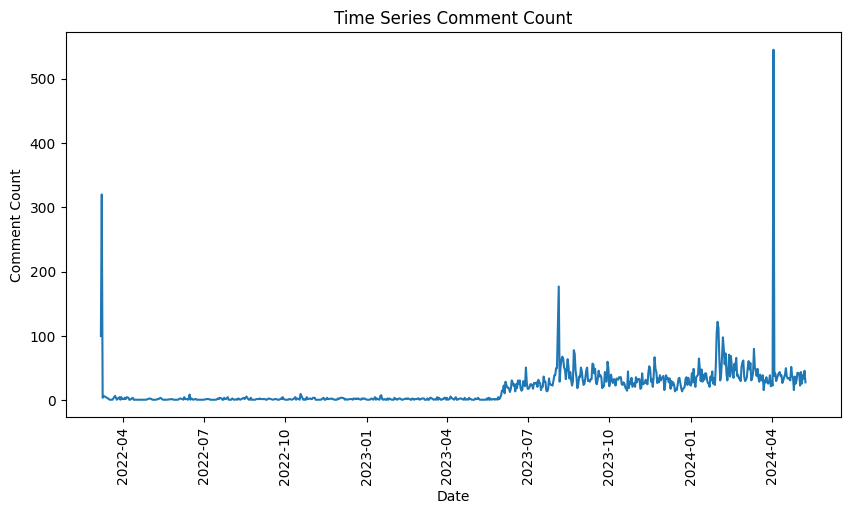

In [ ]:
#plot a line graph to show the time series comment count
plt.figure(figsize=(10,5))
plt.plot(google_df_clean_timeseries_grouped['Review Date'], google_df_clean_timeseries_grouped['Comment'])
plt.xticks(rotation=90)
plt.xlabel('Date')
plt.ylabel('Comment Count')
plt.title('Time Series Comment Count')
plt.show()

In [ ]:
# Create a copy of trustpilot_df_clean dataframe
trustpilot_df_clean_timeseries = trustpilot_df_clean.copy()

In [ ]:
trustpilot_df_clean_timeseries.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
0,2024-05-09 23:29:00,A very good environment,A very good environment,5,en,2024-05-10 08:12:00,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,en,2024-05-10 08:13:00,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,"Extremely busy, no fresh air.",1,en,NaT,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,"Great vibes, fantastic gym",5,en,NaT,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,"Clean, well managed, classes are good.",5,en,2024-05-10 08:14:00,Crayford


In [ ]:
# Change Creation Date column to only Date
trustpilot_df_clean_timeseries['Review Date'] = pd.to_datetime(trustpilot_df_clean_timeseries['Review Created (UTC)'], errors = 'coerce').dt.date

In [ ]:
# Create a new dataframe to group Review Content by Review Date
trustpilot_df_clean_timeseries_grouped = trustpilot_df_clean_timeseries.groupby('Review Date').agg({'Review Content': 'count'}).reset_index()

In [ ]:
# Sort the dataframe by Review Content count in ascending order
trustpilot_df_clean_timeseries_grouped = trustpilot_df_clean_timeseries_grouped.sort_values(by='Review Date', ascending=True)

In [ ]:
# show the top 10 rows sorted in descending order of comment count
trustpilot_df_clean_timeseries_grouped.sort_values(by ='Review Content', ascending= False).head(10)

,Review Date,Review Content
152,2023-10-15,469
219,2023-12-21,358
220,2023-12-22,321
50,2023-07-05,276
155,2023-10-18,255
20,2023-06-05,251
153,2023-10-16,229
151,2023-10-14,213
51,2023-07-06,212
218,2023-12-20,198


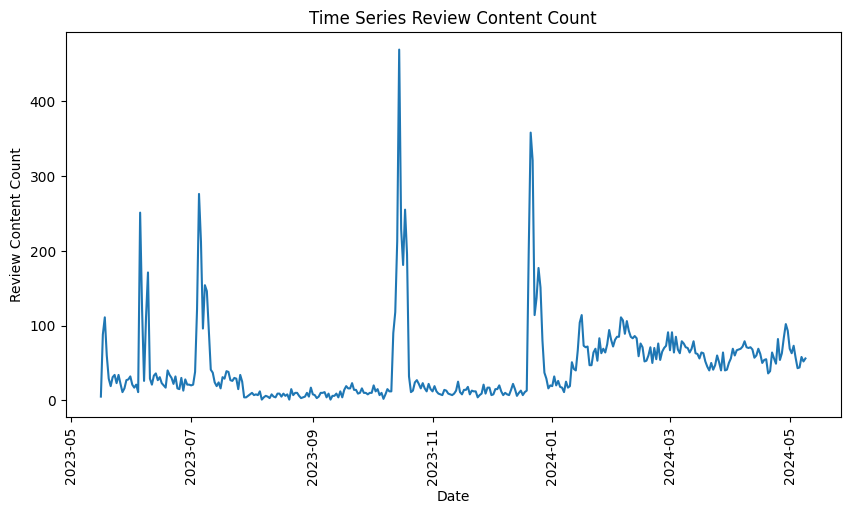

In [ ]:
#plot a line graph to show the time series Review Content count
plt.figure(figsize=(10,5))
plt.plot(trustpilot_df_clean_timeseries_grouped['Review Date'], trustpilot_df_clean_timeseries_grouped['Review Content'])
plt.xticks(rotation=90)
plt.xlabel('Date')
plt.ylabel('Review Content Count')
plt.title('Time Series Review Content Count')
plt.show()

TrustPilot reviews have started approximately an year later to Google reviews. Though there were google reviews in 2022, after the launch, it peaked for only the first few days, after that it was relatively flat until around May/June of 2023. This was the same time frame during which Trustpilot reviews have also started to appear. Trustpilot reviews seem to be spiking every few months. Google reviews don't show such spikes however customers are active on both the review portals. Huge spikes on Trustpilot reviews may be attributed to start of new batches or campaigns, however this assumption needs to be validated with client as customer onboarding related information is not available and hence not considered. It would also be helpful to separately review the reviews during this spikes. One other recommended analysis is to look at top locations by review and analyse the temporal data, to isolate if these are specific to any particular location or club.

## 2.3 Perform preprocessing of the data

In [ ]:
# Create a function to clean specific column from a dataset to do the following: Change to lower case, remove stopwords using NLTK, and remove numbers
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string


# Download necessary NLTK data.
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk import word_tokenize

# Initialize the Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define lemmatization function
def lemmatize_text(text):
    tokens = word_tokenize(text)  # Tokenize the text
    tokens = [word.lower() for word in tokens if word not in stop_words and word not in string.punctuation]
    lemmas = [lemmatizer.lemmatize(token) for token in tokens]  # Lemmatize tokens
    return " ".join(lemmas)

In [ ]:
def clean_column(df, column):

    df[column] = df[column].astype(str)

    df[column] = df[column].str.lower()
    # Use NLTK stopwords to remove stopwords
    stop_words = set(stopwords.words('english'))
    df[column] = df[column].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

    # Apply lemmatization to each row
    df[column] = df[column].apply(lambda x: lemmatize_text(x))


    # Remove numbers
    # df[column] = df[column].str.replace('\d+', ' ')
    # df[column] = df[column].apply(lambda x: ' '.join([word for word in x.split() if not word.isnumeric()]))
    # Commented both methods as it did not remove number which might have been in string format.

    # Remove numbers which may be in string format. Tested on both datasets
    df[column] = df[column].apply(lambda x: re.sub(r'\d+', '', x))

    # Remove punctuation
    df[column] = df[column].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
    # Remove single quotes '
    df[column] = df[column].str.replace("’", '')
    # Remove double quotes ""
    df[column] = df[column].str.replace('"', '')

    # Remove list of words below
    wordsToRemove = ['client name']
    for word in wordsToRemove:
        df[column] = df[column].str.replace(word, '')
    # Remove extra spaces
    df[column] = df[column].str.strip()

    # Remove words from df[column] if they are less and or equal to 2 characters
    df[column] = df[column].apply(lambda x: ' '.join([w for w in x.split() if len(w)>2]))

    return df

Finally, removed 'client name', digit viz. 247, 7 etc. Also removed all 2 and below characters as 'it' and 's' were the top frequency items below refining function- clean_column. Commented the possible incorrect statements.

In [ ]:
# Clean Comment column from google_df_clean dataset using clean_column function
google_df_clean = clean_column(google_df_clean, 'Comment')
google_df_clean.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,many student two local college leave rubbish c...,1
2,London Holborn,2024-05-09 22:08:14,best range equipment cheaper regular professio...,5
3,Cheshunt Brookfield Shopping Park,2024-05-09 21:58:07,good busy tend get busy late afternoon hardly ...,4
4,Bristol Union Gate,2024-05-09 21:48:00,current member quite dirty often soap bathroom...,1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,kom betalte prøvetime centret fik blot rundvis...,1


In [ ]:
# Clean Review Content column from trustpilot_df_clean dataset using clean_column function
trustpilot_df_clean = clean_column(trustpilot_df_clean, 'Review Content')
trustpilot_df_clean.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
0,2024-05-09 23:29:00,A very good environment,good environment,5,en,2024-05-10 08:12:00,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,love part superb value money time day love app...,5,en,2024-05-10 08:13:00,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,extremely busy fresh air,1,en,NaT,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,great vibe fantastic,5,en,NaT,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,clean well managed class good,5,en,2024-05-10 08:14:00,Crayford


In [ ]:
# Check if Review Content has any digits
trustpilot_df_clean[trustpilot_df_clean['Review Content'].str.contains('\d')]
#trustpilot_df_clean.shape

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name


In [ ]:
google_df_clean[google_df_clean['Comment'].str.contains('\d')]

,Club's Name,Creation Date,Comment,Overall Score


In [ ]:
# Get a count of null values in Review Content column
trustpilot_df_clean['Review Content'].isnull().sum()

np.int64(0)

In [ ]:
google_df_clean_copy = google_df_clean.copy()
trustpilot_df_clean_copy = trustpilot_df_clean.copy()

## 2.4 Tokenise the data using word_tokenize from NLTK

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
# Create a function to tokenize comments from each dataset
def tokenize_comments(df, column):
    df[column] = df[column].apply(word_tokenize)

    # Lemmetize df[column]
    lemmatizer = WordNetLemmatizer()
    df[column] = df[column].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
    return df

In [ ]:
# Create a new data with only the tokenized data from Comments from google_df_clean and Review Content from trustpilot_df_clean
google_df_clean_tokenized = tokenize_comments(google_df_clean_copy, 'Comment')
trustpilot_df_clean_tokenized = tokenize_comments(trustpilot_df_clean_copy, 'Review Content')

In [ ]:
google_df_clean_tokenized.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,"[many, student, two, local, college, leave, ru...",1
2,London Holborn,2024-05-09 22:08:14,"[best, range, equipment, cheaper, regular, pro...",5
3,Cheshunt Brookfield Shopping Park,2024-05-09 21:58:07,"[good, busy, tend, get, busy, late, afternoon,...",4
4,Bristol Union Gate,2024-05-09 21:48:00,"[current, member, quite, dirty, often, soap, b...",1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,"[kom, betalte, prøvetime, centret, fik, blot, ...",1


In [ ]:
trustpilot_df_clean_tokenized.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
0,2024-05-09 23:29:00,A very good environment,"[good, environment]",5,en,2024-05-10 08:12:00,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,"[love, part, superb, value, money, time, day, ...",5,en,2024-05-10 08:13:00,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,"[extremely, busy, fresh, air]",1,en,NaT,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,"[great, vibe, fantastic]",5,en,NaT,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,"[clean, well, managed, class, good]",5,en,2024-05-10 08:14:00,Crayford


In [ ]:
# Convert google_df_clean_tokenized[Comment] to a single list
google_comments_list = google_df_clean_tokenized['Comment'].tolist()
trustpilot_comments_list = trustpilot_df_clean_tokenized['Review Content'].tolist()

In [ ]:
# Create a function to find frequecny distribution of words in a list and plot frequency distribution plot
from nltk.probability import FreqDist
from wordcloud import WordCloud

def find_freq_dist(list, title):
    # Find frequency distribution
    freq_dist = FreqDist()
    for comment in list:
        freq_dist.update(comment)
    freq_dist.plot(10)
    # Add a title
    plt.title(f'Top 10 words: {title}')
    # Show the plot
    plt.show()


    # Convert freq_dist to pandas dataframe
    freq_dist_df = pd.DataFrame.from_dict(freq_dist, orient='index')
    # freq_dist_df.columns = ['Frequency']

    # Plot histogram
    plt.figure(figsize=(10,5))
    plt.bar(freq_dist_df.sort_values(by=0, ascending=False).head(10).index, freq_dist_df.sort_values(by=0, ascending=False).head(10)[0])
    plt.xticks(rotation=90)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title(f'Histogram : {title}')
    plt.show()

    # Plot word cloud
    wordcloud = WordCloud(width=800, height=800, background_color='white', min_font_size=10).generate_from_frequencies(freq_dist)
    plt.figure(figsize=(8,8), facecolor=None)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.tight_layout(pad=10)
    plt.title(f'WordCloud : {title}')
    plt.show()

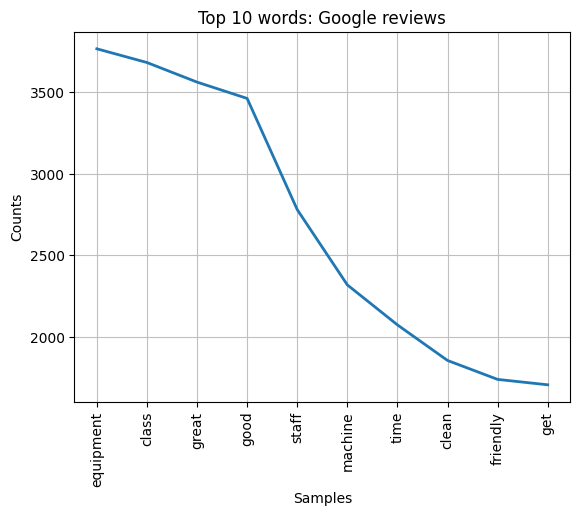

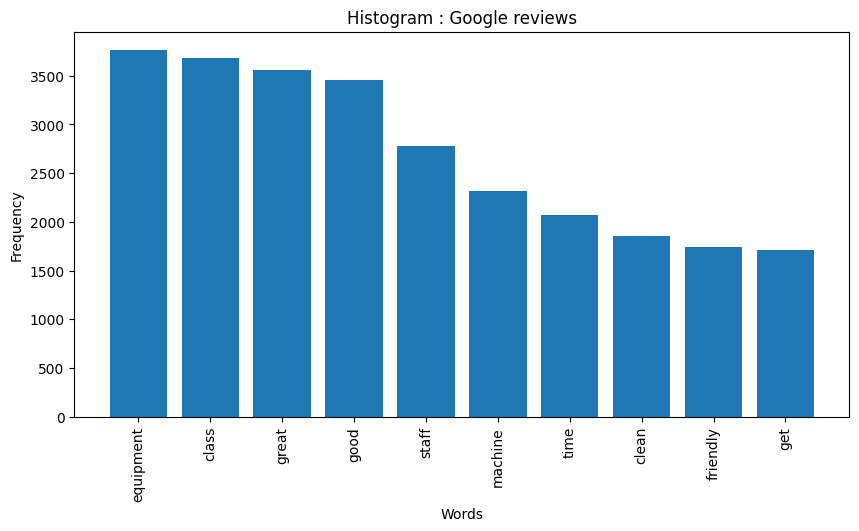

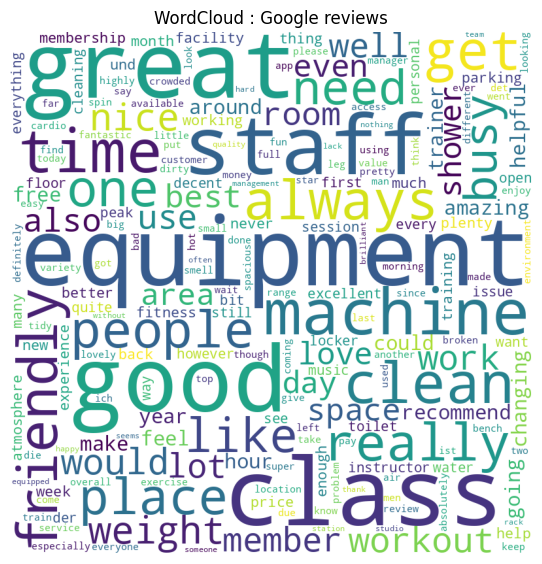

In [ ]:
# Plot Frequency distribution, Histogram and Word cloud
find_freq_dist(google_comments_list,'Google reviews')


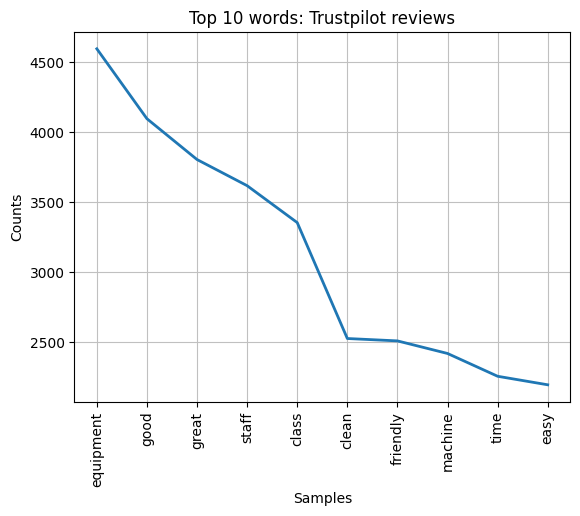

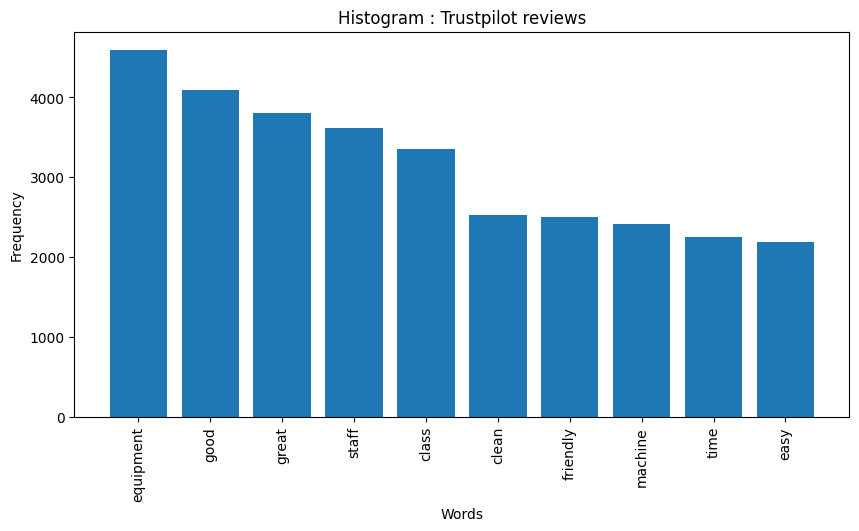

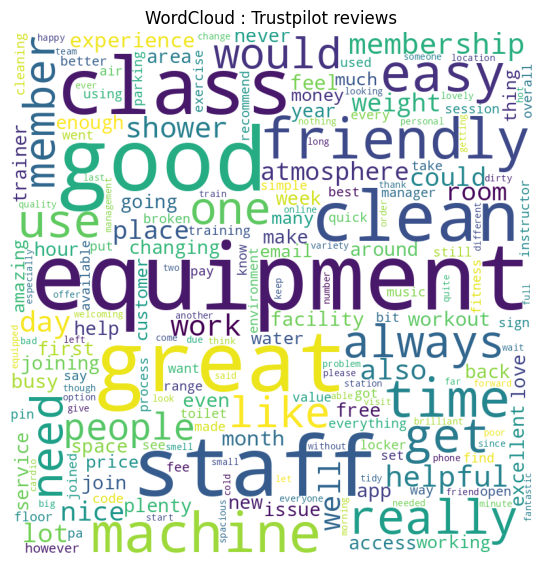

In [ ]:
# Plot Frequency distribution, Histogram and Word cloud
find_freq_dist(trustpilot_comments_list, 'Trustpilot reviews')

Both wordclouds show very similar sentiments which do look positive overall. However the goal is the identify negative sentiments to suggest appropriate actions, continuing the analysis limiting to negative reveiw. Further analysis will be continued on Negative reviews where Overall score is <3.

## 2.5 Dataframe with only negative reviews
use google_df_clean & trustpilot_df_clean

In [ ]:
# Filter Overall Score <3  from google_df_clean to create a new pandas dataframe
google_df_clean_negative = google_df_clean[google_df_clean['Overall Score'] < 3]
google_df_clean_negative.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,many student two local college leave rubbish c...,1
4,Bristol Union Gate,2024-05-09 21:48:00,current member quite dirty often soap bathroom...,1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,kom betalte prøvetime centret fik blot rundvis...,1
7,New Barnet,2024-05-09 20:16:04,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,2024-05-09 17:03:50,access empty assistance gain access fault forg...,2


In [ ]:
# Drop Creation Date
google_df_clean_negative = google_df_clean_negative.drop('Creation Date', axis=1)
google_df_clean_negative.head()


,Club's Name,Comment,Overall Score
1,Cambridge Leisure Park,many student two local college leave rubbish c...,1
4,Bristol Union Gate,current member quite dirty often soap bathroom...,1
5,"209 - Slagelse, Jernbanegade",kom betalte prøvetime centret fik blot rundvis...,1
7,New Barnet,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2


In [ ]:
# Rename Column names as Location, Review Comment and Rating
google_df_clean_negative.columns = ['Location', 'Review Comment', 'Rating']
google_df_clean_negative.head()

,Location,Review Comment,Rating
1,Cambridge Leisure Park,many student two local college leave rubbish c...,1
4,Bristol Union Gate,current member quite dirty often soap bathroom...,1
5,"209 - Slagelse, Jernbanegade",kom betalte prøvetime centret fik blot rundvis...,1
7,New Barnet,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2


In [ ]:
# Filter Overall Score <3  from trustpilot_df_clean to create a new pandas dataframe
trustpilot_df_clean_negative = trustpilot_df_clean[trustpilot_df_clean['Review Stars'] < 3]
trustpilot_df_clean_negative.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
2,2024-05-09 22:51:00,Extremely busy,extremely busy fresh air,1,en,NaT,Sutton Times Square
19,2024-05-09 18:09:00,The men’s changing rooms smell bad,men changing room smell bad need deep clean so...,2,en,NaT,Leeds City Centre South
35,2024-05-09 13:25:00,All I wanted to do was set up another…,wanted set another debit card direct debit opt...,1,en,NaT,NaN
36,2024-05-09 13:17:00,What ever you do don’t downgrade your…,ever downgrade membership core plus… cancel me...,1,en,NaT,NaN
38,2024-05-09 12:35:00,Awful Gyms,poor parking enough kit unhelpful trainers sta...,2,en,NaT,NaN


In [ ]:
# Drop all other columns other than Review Content, Review Stars and Location Name from trustpilot_df_clean_negative
trustpilot_df_clean_negative = trustpilot_df_clean_negative.drop(['Review Created (UTC)','Review Title', 'Review Language', 'Company Reply Date (UTC)'], axis=1)
trustpilot_df_clean_negative.head()

,Review Content,Review Stars,Location Name
2,extremely busy fresh air,1,Sutton Times Square
19,men changing room smell bad need deep clean so...,2,Leeds City Centre South
35,wanted set another debit card direct debit opt...,1,NaN
36,ever downgrade membership core plus… cancel me...,1,NaN
38,poor parking enough kit unhelpful trainers sta...,2,NaN


In [ ]:
# Rename Column names as Location, Review Comment and Rating
trustpilot_df_clean_negative.columns = ['Location','Rating', 'Review Comment']
trustpilot_df_clean_negative.head()

,Location,Rating,Review Comment
2,extremely busy fresh air,1,Sutton Times Square
19,men changing room smell bad need deep clean so...,2,Leeds City Centre South
35,wanted set another debit card direct debit opt...,1,NaN
36,ever downgrade membership core plus… cancel me...,1,NaN
38,poor parking enough kit unhelpful trainers sta...,2,NaN


## 2.6 Negative reviews Frequency distribution and Word cloud

In [ ]:
# Filter Overall Score <3 from google_df_clean_tokenized to create a new pandas dataframe
google_df_clean_tokenized_negative = google_df_clean_tokenized[google_df_clean_tokenized['Overall Score'] < 3]
google_df_clean_tokenized_negative.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,"[many, student, two, local, college, leave, ru...",1
4,Bristol Union Gate,2024-05-09 21:48:00,"[current, member, quite, dirty, often, soap, b...",1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,"[kom, betalte, prøvetime, centret, fik, blot, ...",1
7,New Barnet,2024-05-09 20:16:04,"[way, hot, even, workout, window, open, barely...",2
19,Manchester Cheetham Hill,2024-05-09 17:03:50,"[access, empty, assistance, gain, access, faul...",2


In [ ]:
google_neg_comments_list = google_df_clean_tokenized_negative['Comment'].tolist()

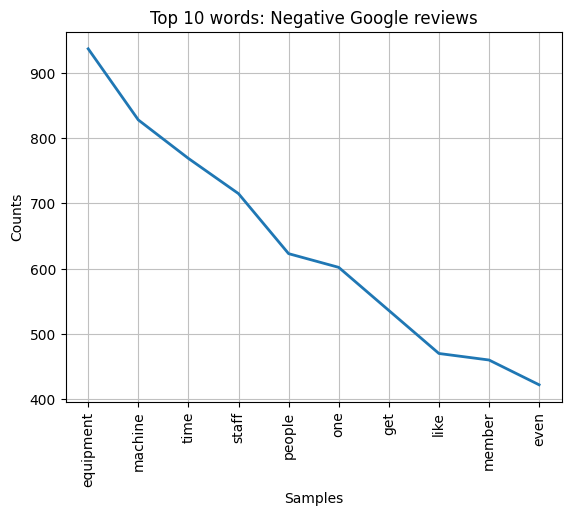

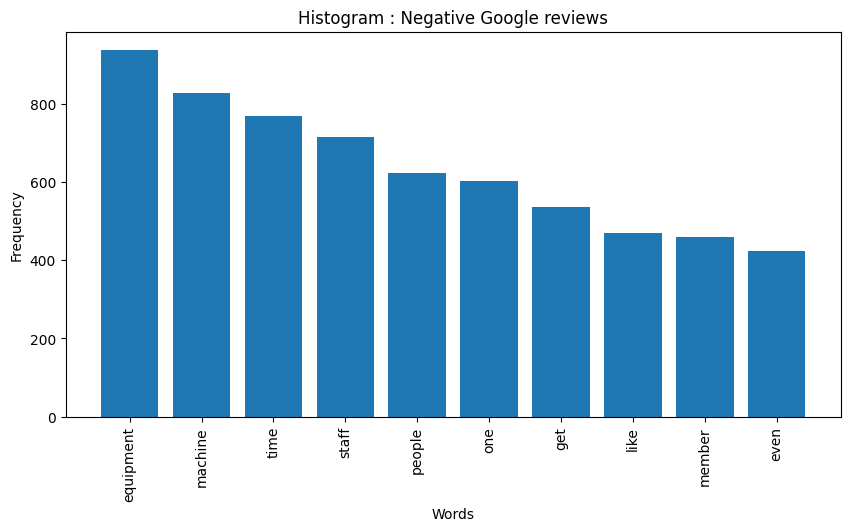

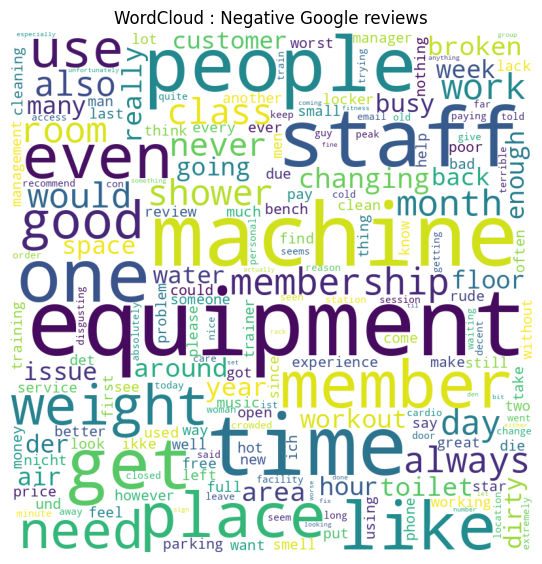

In [ ]:
# Plot Frequency distribution, Histogram and Word cloud
find_freq_dist(google_neg_comments_list,'Negative Google reviews')

In [ ]:
trustpilot_df_clean_tokenized.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
0,2024-05-09 23:29:00,A very good environment,"[good, environment]",5,en,2024-05-10 08:12:00,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,"[love, part, superb, value, money, time, day, ...",5,en,2024-05-10 08:13:00,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,"[extremely, busy, fresh, air]",1,en,NaT,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,"[great, vibe, fantastic]",5,en,NaT,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,"[clean, well, managed, class, good]",5,en,2024-05-10 08:14:00,Crayford


In [ ]:
# Filter Overall Score <3  from trustpilot_df_clean_tokenized to create a new pandas dataframe
trustpilot_df_clean_tokenized_negative = trustpilot_df_clean_tokenized[trustpilot_df_clean_tokenized['Review Stars'] < 3]
trustpilot_df_clean_tokenized_negative.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
2,2024-05-09 22:51:00,Extremely busy,"[extremely, busy, fresh, air]",1,en,NaT,Sutton Times Square
19,2024-05-09 18:09:00,The men’s changing rooms smell bad,"[men, changing, room, smell, bad, need, deep, ...",2,en,NaT,Leeds City Centre South
35,2024-05-09 13:25:00,All I wanted to do was set up another…,"[wanted, set, another, debit, card, direct, de...",1,en,NaT,NaN
36,2024-05-09 13:17:00,What ever you do don’t downgrade your…,"[ever, downgrade, membership, core, plus…, can...",1,en,NaT,NaN
38,2024-05-09 12:35:00,Awful Gyms,"[poor, parking, enough, kit, unhelpful, traine...",2,en,NaT,NaN


In [ ]:
trustpilot_neg_comments_list = trustpilot_df_clean_tokenized_negative['Review Content'].tolist()

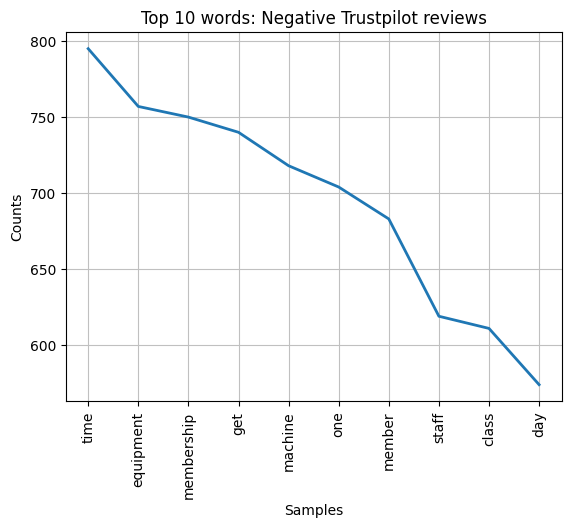

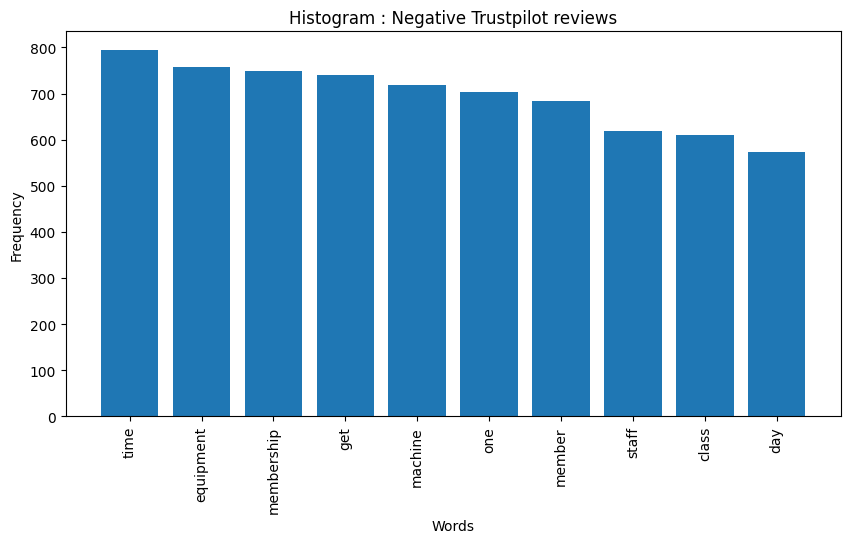

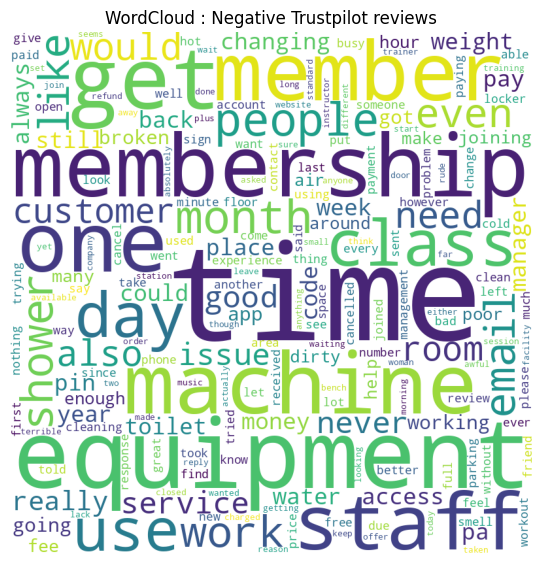

In [ ]:
# Plot Frequency distribution, Histogram and Word cloud
find_freq_dist(trustpilot_neg_comments_list, 'Negative Trustpilot reviews')

# 3. Conducting initial topic modelling

With the data frame created in the previous step:

• Filtered out the reviews that are from the locations common to both data sets.

• Merged the reviews to form a new list.

## 3.1 Merged dataset with negative reivews from common locations

In [ ]:
google_df_clean

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,many student two local college leave rubbish c...,1
2,London Holborn,2024-05-09 22:08:14,best range equipment cheaper regular professio...,5
3,Cheshunt Brookfield Shopping Park,2024-05-09 21:58:07,good busy tend get busy late afternoon hardly ...,4
4,Bristol Union Gate,2024-05-09 21:48:00,current member quite dirty often soap bathroom...,1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,kom betalte prøvetime centret fik blot rundvis...,1
...,...,...,...,...
23244,London Muswell Hill,2022-03-07 20:46:38,great instructor please make sure james make p...,5
23245,Sheffield Millhouses,2022-03-07 20:36:22,chiara class great fun fab instructor peach,5
23246,Sheffield Millhouses,2022-03-07 20:36:22,perfect,5
23247,Sheffield Millhouses,2022-03-07 20:36:21,loved pump class today,4


In [ ]:
trustpilot_df_clean

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
0,2024-05-09 23:29:00,A very good environment,good environment,5,en,2024-05-10 08:12:00,Solihull Sears Retail Park
1,2024-05-09 23:11:00,I love to be part of this gym,love part superb value money time day love app...,5,en,2024-05-10 08:13:00,Aylesbury
2,2024-05-09 22:51:00,Extremely busy,extremely busy fresh air,1,en,NaT,Sutton Times Square
3,2024-05-09 22:35:00,Great vibes,great vibe fantastic,5,en,NaT,London Finchley
4,2024-05-09 22:30:00,Everything it needs to be,clean well managed class good,5,en,2024-05-10 08:14:00,Crayford
...,...,...,...,...,...,...,...
16668,2023-05-16 23:30:00,Classes at PureGym,enjoy class weight etc easy use class size qui...,4,en,2023-05-24 14:49:00,Rushden
16669,2023-05-16 23:18:00,Happy and helpful staff,happy helpful staff feel comfortable ask advic...,5,en,2023-05-24 13:50:00,Yate
16670,2023-05-16 23:16:00,Showers never maintain the same temp.,shower never maintain temp clean enough either,4,en,2023-05-24 13:51:00,NaN
16671,2023-05-16 23:15:00,Getting back to gym after be off for 3…,getting back month well ask member staff show ...,5,en,2023-05-24 13:51:00,NaN


In [ ]:
# Common location list between google and trustpilot reviews
commonLocations

['Manchester First Street',
 'Didcot',
 'Glasgow Robroyston',
 'London Greenwich Movement',
 'Falkirk',
 'Newcastle Eldon Garden',
 'Northampton Weston Favell',
 'Bristol Eastgate',
 'London Great Portland Street',
 'Edinburgh Waterfront',
 'Newbury',
 'Derby',
 'Bromsgrove Retail Park',
 'Leeds City Centre North',
 'Paisley',
 'Bradford Idle',
 'London Wandsworth',
 'Liverpool Central',
 'Nottingham West Bridgford',
 'Ipswich Ravenswood',
 'Billericay',
 'Bromborough',
 'Bristol Harbourside',
 'Grimsby',
 'London Bank',
 'Dudley Tipton',
 'Plymouth Alexandra Road',
 'York',
 'Gloucester Retail Park',
 'Newport Gwent',
 'Cambridge Leisure Park',
 'London Marylebone',
 'Milton Keynes Winterhill',
 'Barnstaple',
 'Basildon',
 'London Park Royal',
 'Glossop',
 'London Enfield',
 'Loughborough',
 'Poole',
 'London St Pauls',
 'Tonbridge',
 'Manchester Stretford',
 'London Putney',
 'London Edgware',
 'Rayleigh',
 'Manchester Exchange Quay',
 'Bletchley',
 'Hereford',
 'Redditch Ringway',
 

In [ ]:
# Filter Overall Score <3  from google_df_clean to create a new pandas dataframe
google_df_clean_negative = google_df_clean[google_df_clean['Overall Score'] < 3]
google_df_clean_negative.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,many student two local college leave rubbish c...,1
4,Bristol Union Gate,2024-05-09 21:48:00,current member quite dirty often soap bathroom...,1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,kom betalte prøvetime centret fik blot rundvis...,1
7,New Barnet,2024-05-09 20:16:04,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,2024-05-09 17:03:50,access empty assistance gain access fault forg...,2


In [ ]:
# Filter Overall Score <3  from trustpilot_df_clean to create a new pandas dataframe
trustpilot_df_clean_negative = trustpilot_df_clean[trustpilot_df_clean['Review Stars'] < 3]
trustpilot_df_clean_negative.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
2,2024-05-09 22:51:00,Extremely busy,extremely busy fresh air,1,en,NaT,Sutton Times Square
19,2024-05-09 18:09:00,The men’s changing rooms smell bad,men changing room smell bad need deep clean so...,2,en,NaT,Leeds City Centre South
35,2024-05-09 13:25:00,All I wanted to do was set up another…,wanted set another debit card direct debit opt...,1,en,NaT,NaN
36,2024-05-09 13:17:00,What ever you do don’t downgrade your…,ever downgrade membership core plus… cancel me...,1,en,NaT,NaN
38,2024-05-09 12:35:00,Awful Gyms,poor parking enough kit unhelpful trainers sta...,2,en,NaT,NaN


In [ ]:
# Create a new dataframe from google_df_clean where Club's Name is same as from commonLocations list. Same for trustpilot_df_clean where Location Name is same as from commonLocations list

google_df_negative_common = google_df_clean_negative[google_df_clean_negative['Club\'s Name'].isin(commonLocations)]
google_df_negative_common.head()


,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,many student two local college leave rubbish c...,1
4,Bristol Union Gate,2024-05-09 21:48:00,current member quite dirty often soap bathroom...,1
7,New Barnet,2024-05-09 20:16:04,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,2024-05-09 17:03:50,access empty assistance gain access fault forg...,2
29,Newcastle Eldon Garden,2024-05-09 08:38:07,year finally leaving gutted staff lovely stand...,2


In [ ]:
trustpilot_df_negative_common = trustpilot_df_clean_negative[trustpilot_df_clean_negative['Location Name'].isin(commonLocations)]
trustpilot_df_negative_common.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
2,2024-05-09 22:51:00,Extremely busy,extremely busy fresh air,1,en,NaT,Sutton Times Square
19,2024-05-09 18:09:00,The men’s changing rooms smell bad,men changing room smell bad need deep clean so...,2,en,NaT,Leeds City Centre South
48,2024-05-09 09:16:00,No one was cleaning the equipment after…,one cleaning equipment use cleaning station hi...,1,en,NaT,Dunfermline
51,2024-05-09 08:03:00,Not the best experience at 7am on a…,best experience week day bought day pas receiv...,1,en,NaT,Bristol Harbourside
69,2024-05-08 18:16:00,Staff are great but not the company,staff hand tied surely head office could bring...,1,en,NaT,Sunderland


In [ ]:
google_neg_reviews_comLocation = pd.DataFrame(google_df_negative_common[['Club\'s Name','Comment','Overall Score']])
google_neg_reviews_comLocation.head()

,Club's Name,Comment,Overall Score
1,Cambridge Leisure Park,many student two local college leave rubbish c...,1
4,Bristol Union Gate,current member quite dirty often soap bathroom...,1
7,New Barnet,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
29,Newcastle Eldon Garden,year finally leaving gutted staff lovely stand...,2


In [ ]:
google_neg_reviews_comLocation.shape

(2098, 3)

In [ ]:
# Rename Column names as Location, Review Comment and Rating
google_neg_reviews_comLocation.columns = ['Location', 'Review Comment', 'Rating']
google_neg_reviews_comLocation.head()

,Location,Review Comment,Rating
1,Cambridge Leisure Park,many student two local college leave rubbish c...,1
4,Bristol Union Gate,current member quite dirty often soap bathroom...,1
7,New Barnet,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
29,Newcastle Eldon Garden,year finally leaving gutted staff lovely stand...,2


In [ ]:
trustpilot_neg_reviews_comLocation = pd.DataFrame(trustpilot_df_negative_common[['Location Name','Review Content','Review Stars']])
trustpilot_neg_reviews_comLocation.head()

,Location Name,Review Content,Review Stars
2,Sutton Times Square,extremely busy fresh air,1
19,Leeds City Centre South,men changing room smell bad need deep clean so...,2
48,Dunfermline,one cleaning equipment use cleaning station hi...,1
51,Bristol Harbourside,best experience week day bought day pas receiv...,1
69,Sunderland,staff hand tied surely head office could bring...,1


In [ ]:
trustpilot_neg_reviews_comLocation.shape

(1849, 3)

In [ ]:
# Rename Column names as Location, Review Comment and Rating
trustpilot_neg_reviews_comLocation.columns = ['Location', 'Review Comment', 'Rating']
trustpilot_neg_reviews_comLocation.head()

,Location,Review Comment,Rating
2,Sutton Times Square,extremely busy fresh air,1
19,Leeds City Centre South,men changing room smell bad need deep clean so...,2
48,Dunfermline,one cleaning equipment use cleaning station hi...,1
51,Bristol Harbourside,best experience week day bought day pas receiv...,1
69,Sunderland,staff hand tied surely head office could bring...,1


In [ ]:
# Merge merged_google_reviews_df and merged_trustpilot_reviews_df
merged_reviews_df = pd.concat([google_neg_reviews_comLocation, trustpilot_neg_reviews_comLocation])
merged_reviews_df.head()

,Location,Review Comment,Rating
1,Cambridge Leisure Park,many student two local college leave rubbish c...,1
4,Bristol Union Gate,current member quite dirty often soap bathroom...,1
7,New Barnet,way hot even workout window open barely work s...,2
19,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
29,Newcastle Eldon Garden,year finally leaving gutted staff lovely stand...,2


In [ ]:
merged_reviews_df.shape

(3947, 3)

In [ ]:
merged_reviews_df = merged_reviews_df.reset_index(drop=True)

## 3.2 Helper function: Save to Numpy file

In [ ]:
# Create a function to save a pandas dataframe to numpy file

def save_to_numpy(df, filename):
  # Shared filename should be with .npy extension
  df.to_numpy()
  np.save(filename, df)

## 3.3 Save merged_reviews_df as Numpy file for use in further analysis
This dataframe contains all negative reviews from both Google and Trustpilot dataset, where review score is <3

In [ ]:
save_to_numpy(merged_reviews_df, 'merged_negative_reviews_df.npy')

## 3.4 Load dataset: merged_review_neg_emotion_anger.npy

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
loaded_merged_negative_reviews_df = np.load('merged_negative_reviews_df.npy', allow_pickle=True)

In [ ]:
# Convert loaded numpy dataset to pandas dataframe
merged_reviews_df = pd.DataFrame(loaded_merged_negative_reviews_df)
merged_reviews_df.head()

,0,1,2
0,Cambridge Leisure Park,many student two local college leave rubbish c...,1
1,Bristol Union Gate,current member quite dirty often soap bathroom...,1
2,New Barnet,way hot even workout window open barely work s...,2
3,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
4,Newcastle Eldon Garden,year finally leaving gutted staff lovely stand...,2


In [ ]:
# Rename column as Location, Review Comment, Emotion
merged_reviews_df.columns = ['Location', 'Review Comment', 'Emotion']
merged_reviews_df.head()

,Location,Review Comment,Emotion
0,Cambridge Leisure Park,many student two local college leave rubbish c...,1
1,Bristol Union Gate,current member quite dirty often soap bathroom...,1
2,New Barnet,way hot even workout window open barely work s...,2
3,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
4,Newcastle Eldon Garden,year finally leaving gutted staff lovely stand...,2


In [ ]:
# Reset the index of merged_reviews_top30byLocation before fitting the model
merged_reviews_df = merged_reviews_df.reset_index(drop=True)

# Topic Modeling using BERT

In [ ]:
from transformers import pipeline

In [ ]:
from bertopic import BERTopic

In [ ]:
model = BERTopic(verbose=True)
model.fit(merged_reviews_df['Review Comment'])
topic, probabilities = model.transform(merged_reviews_df['Review Comment'])

2025-03-29 15:33:40,252 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/124 [00:00<?, ?it/s]

2025-03-29 15:35:03,056 - BERTopic - Embedding - Completed ✓
2025-03-29 15:35:03,057 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-29 15:35:27,899 - BERTopic - Dimensionality - Completed ✓
2025-03-29 15:35:27,901 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-29 15:35:28,066 - BERTopic - Cluster - Completed ✓
2025-03-29 15:35:28,074 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-03-29 15:35:28,261 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/124 [00:00<?, ?it/s]

2025-03-29 15:36:49,139 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-03-29 15:36:49,154 - BERTopic - Dimensionality - Completed ✓
2025-03-29 15:36:49,155 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-03-29 15:36:49,323 - BERTopic - Cluster - Completed ✓


Top topics along with their document frequencies.

In [ ]:
model.get_topic_freq().head(10)

,Topic,Count
1,-1,1704
5,0,189
6,1,151
16,2,120
2,3,116
9,4,108
23,5,105
19,6,94
18,7,91
13,8,81


There are high number of outliers noticed by Topic -1, with 1704 documents.

For the top 2 topics, list out the top words.

In [ ]:
model.get_topic(0)

[('air', np.float64(0.06978088372521145)),
 ('conditioning', np.float64(0.04547983763709413)),
 ('hot', np.float64(0.031187691679419625)),
 ('aircon', np.float64(0.03071890152905769)),
 ('con', np.float64(0.026995447450008706)),
 ('heat', np.float64(0.023855381676643122)),
 ('summer', np.float64(0.02316564656372425)),
 ('temperature', np.float64(0.021855635728249275)),
 ('warm', np.float64(0.018346336325636748)),
 ('working', np.float64(0.0180689051653601))]

In [ ]:
model.get_topic(1)

[('class', np.float64(0.10941232172344434)),
 ('instructor', np.float64(0.040819260082364854)),
 ('booked', np.float64(0.0314795294987866)),
 ('cancelled', np.float64(0.021707180068354943)),
 ('spin', np.float64(0.017805845712213282)),
 ('time', np.float64(0.016620035364294038)),
 ('trainer', np.float64(0.016056584766333707)),
 ('minute', np.float64(0.015425274715563016)),
 ('booking', np.float64(0.015398856206727322)),
 ('late', np.float64(0.013490889461516626))]

In [ ]:
model.visualize_topics()

In [ ]:
model.visualize_barchart(top_n_topics=10)

In [ ]:
model.visualize_heatmap()

In [ ]:
hierarchical_topics = model.hierarchical_topics(merged_reviews_df['Review Comment'])
model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 46/46 [00:00<00:00, 183.20it/s]


# Performing further data investigation

Top 20 locations with the highest number of negative reviews

In [ ]:
google_df_clean_negative.shape

(2785, 4)

In [ ]:
# Check if there are any blank cells, or NaN in Club's Name column
google_df_clean_negative['Club\'s Name'].isnull().sum()

np.int64(0)

In [ ]:
google_neg_review_location = pd.DataFrame()

In [ ]:
google_neg_review_location['Location'] = google_df_clean_negative['Club\'s Name']
google_neg_review_location = google_neg_review_location.dropna()
google_neg_review_location = google_neg_review_location.groupby(["Location"])["Location"].count().reset_index(name='google_review_count')

google_neg_review_location_sorted = google_neg_review_location.sort_values(by='google_review_count', ascending=False)
google_neg_review_location_sorted.head(20)

,Location,google_review_count
319,London Stratford,59
330,London Woolwich,26
275,London Canary Wharf,26
285,London Enfield,25
321,London Swiss Cottage,24
311,London Palmers Green,22
124,Birmingham City Centre,21
303,London Leytonstone,21
353,New Barnet,20
137,Bradford Thornbury,19


<Axes: xlabel='Location'>

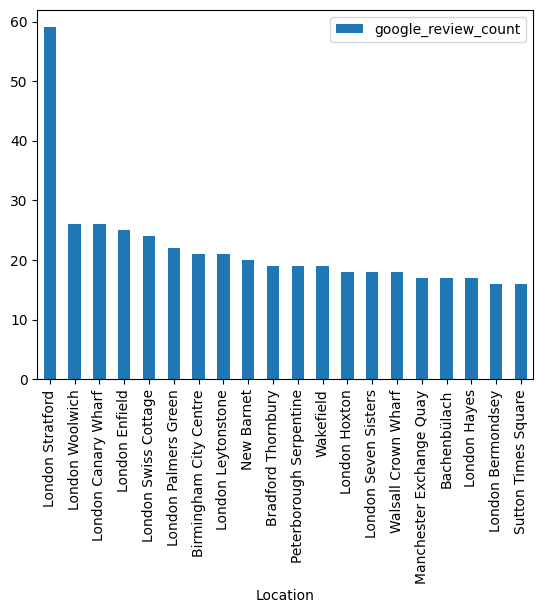

In [ ]:
# Plot a bar graph of top 20 locations and review count
google_neg_review_location_sorted.head(20).plot(kind='bar', x='Location', y='google_review_count')

Majority of negative reviews are from London area. The top 5 gyms with negative reivews are from in and around London, though the reviews are spread across the country. It may not mean other cities are doing better, rather this may be due to higher memberships in London, leading to higher reviews. It is recommended to look at this count in terms of ratio/percentage of memberships. This may be also representation of the possibility of busy lifestyle related challenges, and it is worth investigating and comparing top topics with other cities.

In [ ]:
trustpilot_df_clean_negative.shape

(3508, 7)

In [ ]:
# Check if there are any blank cells, or NaN in Location Name column
trustpilot_df_clean_negative['Location Name'].isnull().sum()

np.int64(1260)

There are around 1260 reviews don't have any location listed. Removed these reviews.

In [ ]:
trustpilot_neg_review_location = pd.DataFrame()

In [ ]:
trustpilot_neg_review_location['Location'] = trustpilot_df_clean_negative['Location Name']
trustpilot_neg_review_location = trustpilot_neg_review_location.dropna()
trustpilot_neg_review_location = trustpilot_neg_review_location.groupby(["Location"])["Location"].count().reset_index(name='trustpilot_review_count')

trustpilot_neg_review_location_sorted = trustpilot_neg_review_location.sort_values(by='trustpilot_review_count', ascending=False)
trustpilot_neg_review_location_sorted.head(20)

,Location,trustpilot_review_count
155,Leicester Walnut Street,50
0,345,45
186,London Enfield,23
219,London Stratford,22
58,Burnham,20
171,London Bermondsey,18
199,London Ilford,18
188,London Finchley,16
215,London Seven Sisters,16
233,Maidenhead,16


<Axes: xlabel='Location'>

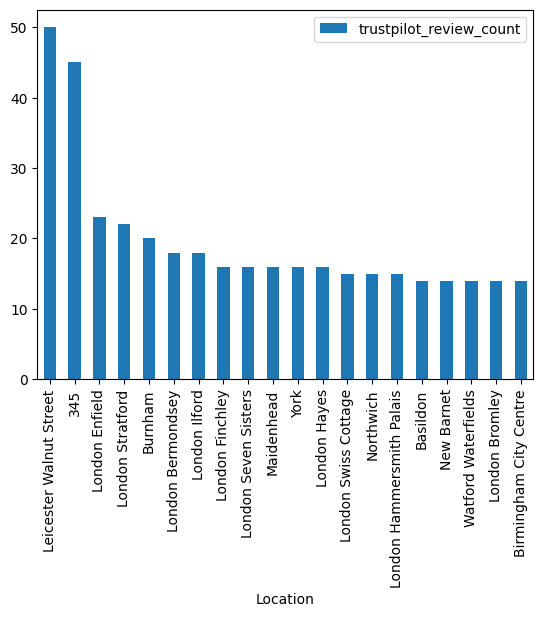

In [ ]:
# Plot a bar graph of top 20 locations and review count
trustpilot_neg_review_location_sorted.head(20).plot(kind='bar', x='Location', y='trustpilot_review_count')

Merge the 2 data sets using Location Name and Club's Name.

Now, list out the following:

• Locations
• Number of Trustpilot reviews for this location
• Number of Google reviews for this location
• Total number of reviews for this location (sum of Google reviews and Trustpilot reviews)

Sort based on the total number of reviews.

In [ ]:
# merge google_neg_review_location_sorted and trustpilot_neg_review_location_sorted
merged_neg_reviews_locations = pd.merge(google_neg_review_location_sorted, trustpilot_neg_review_location_sorted, on='Location', how='left')

# Filled NaN with 0, as dropna() funtion was removing the entire row which had review in either 1
merged_neg_reviews_locations = merged_neg_reviews_locations.dropna()
# merged_neg_reviews_locations = merged_neg_reviews_locations.fillna(0)

# Add Total review count column
merged_neg_reviews_locations['Total Reviews'] = merged_neg_reviews_locations['google_review_count'] + merged_neg_reviews_locations['trustpilot_review_count']

# Sorted table in descending order by 'Total Reviews' column
merged_neg_reviews_locations_sorted = merged_neg_reviews_locations.sort_values(by='Total Reviews', ascending=False)
merged_neg_reviews_locations_sorted.head(20)

,Location,google_review_count,trustpilot_review_count,Total Reviews
0,London Stratford,59,22.0,81.0
57,Leicester Walnut Street,11,50.0,61.0
3,London Enfield,25,23.0,48.0
4,London Swiss Cottage,24,15.0,39.0
6,Birmingham City Centre,21,14.0,35.0
8,New Barnet,20,14.0,34.0
13,London Seven Sisters,18,16.0,34.0
18,London Bermondsey,16,18.0,34.0
17,London Hayes,17,16.0,33.0
9,Bradford Thornbury,19,14.0,33.0


# Top 30 locations by Total Reviews

In [ ]:
merged_neg_reviews_locations_sorted.head(30)

,Location,google_review_count,trustpilot_review_count,Total Reviews
0,London Stratford,59,22.0,81.0
57,Leicester Walnut Street,11,50.0,61.0
3,London Enfield,25,23.0,48.0
4,London Swiss Cottage,24,15.0,39.0
6,Birmingham City Centre,21,14.0,35.0
8,New Barnet,20,14.0,34.0
13,London Seven Sisters,18,16.0,34.0
18,London Bermondsey,16,18.0,34.0
17,London Hayes,17,16.0,33.0
9,Bradford Thornbury,19,14.0,33.0


### Word frequency and word cloud-top 30 locations
Redo the word frequency and word cloud. Comment on the results, and highlight if the results are different from the first run.

Using google_df_clean_tokenized_negative, trustpilot_df_clean_tokenized_negative data set to compare reviews only from top 30 locations

In [ ]:
google_df_clean_tokenized_negative.head()

,Club's Name,Creation Date,Comment,Overall Score
1,Cambridge Leisure Park,2024-05-09 22:48:39,"[many, student, two, local, college, leave, ru...",1
4,Bristol Union Gate,2024-05-09 21:48:00,"[current, member, quite, dirty, often, soap, b...",1
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,"[kom, betalte, prøvetime, centret, fik, blot, ...",1
7,New Barnet,2024-05-09 20:16:04,"[way, hot, even, workout, window, open, barely...",2
19,Manchester Cheetham Hill,2024-05-09 17:03:50,"[access, empty, assistance, gain, access, faul...",2


In [ ]:
google_neg_common_top30byLocation = google_df_clean_tokenized_negative[google_df_clean_tokenized_negative['Club\'s Name'].isin(merged_neg_reviews_locations_sorted['Location'].head(30))]
google_neg_common_top30byLocation.head()

,Club's Name,Creation Date,Comment,Overall Score
7,New Barnet,2024-05-09 20:16:04,"[way, hot, even, workout, window, open, barely...",2
65,New Barnet,2024-05-08 20:20:02,"[airconditioning, doesnt, work]",1
168,London Hoxton,2024-05-07 14:10:01,"[staff, allowed, blame, annoying, people, hoxt...",1
172,Walsall Crown Wharf,2024-05-07 12:59:12,"[absolute, filthy, toilet, machine, machine, u...",1
219,Burnham,2024-05-06 17:26:09,"[overcrowded, full, teenager, look, plus, woul...",1


In [ ]:
google_neg_common_top30byLocation["Club's Name"].unique()

array(['New Barnet', 'London Hoxton', 'Walsall Crown Wharf', 'Burnham',
       'Leicester St Georges Way', 'London Seven Sisters',
       'London Bermondsey', 'London Beckton', 'London Leytonstone',
       'London Holborn', 'London Muswell Hill', 'London Bromley',
       'Manchester Exchange Quay', 'London Enfield', 'Maidenhead',
       'London Hammersmith Palais', 'Nottingham Colwick',
       'London Canary Wharf', 'London Stratford', 'Basildon',
       'London Finchley', 'Wakefield', 'London Park Royal',
       'Birmingham City Centre', 'Bradford Thornbury',
       'Birmingham Beaufort Park', 'Sutton Times Square', 'London Hayes',
       'Leicester Walnut Street', 'London Swiss Cottage'], dtype=object)

In [ ]:
google_neg_top30_comments_list = google_neg_common_top30byLocation['Comment'].tolist()

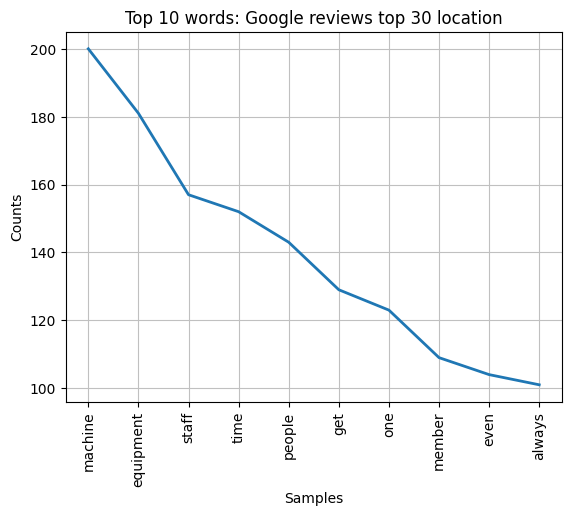

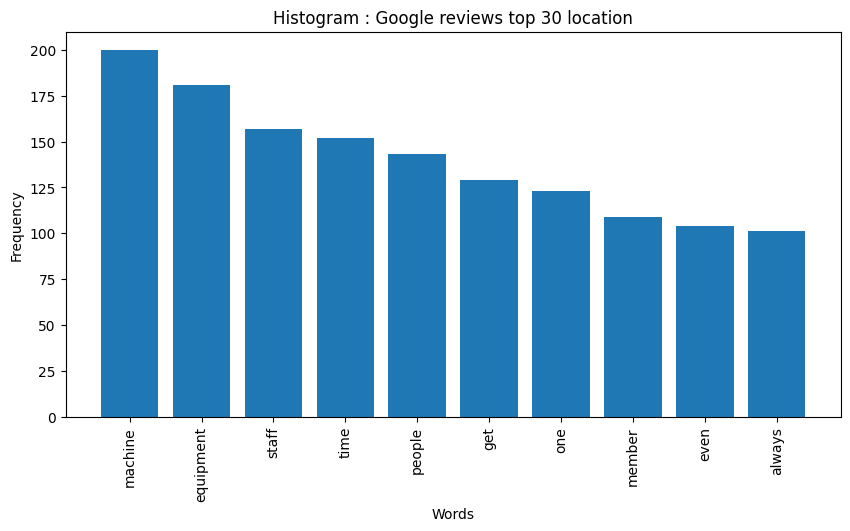

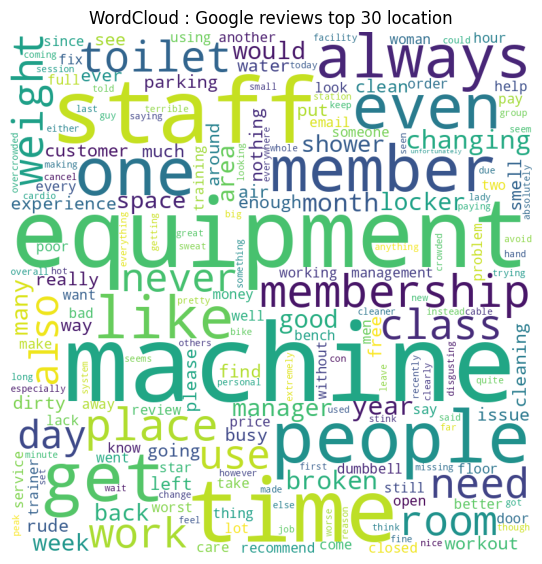

In [ ]:
# Plot Frequency distribution, Histogram and Word cloud
find_freq_dist(google_neg_top30_comments_list, 'Google reviews top 30 location')

In [ ]:
trustpilot_df_clean_tokenized_negative.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
2,2024-05-09 22:51:00,Extremely busy,"[extremely, busy, fresh, air]",1,en,NaT,Sutton Times Square
19,2024-05-09 18:09:00,The men’s changing rooms smell bad,"[men, changing, room, smell, bad, need, deep, ...",2,en,NaT,Leeds City Centre South
35,2024-05-09 13:25:00,All I wanted to do was set up another…,"[wanted, set, another, debit, card, direct, de...",1,en,NaT,NaN
36,2024-05-09 13:17:00,What ever you do don’t downgrade your…,"[ever, downgrade, membership, core, plus…, can...",1,en,NaT,NaN
38,2024-05-09 12:35:00,Awful Gyms,"[poor, parking, enough, kit, unhelpful, traine...",2,en,NaT,NaN


In [ ]:
trustpilot_neg_common_top30byLocation = trustpilot_df_clean_tokenized_negative[trustpilot_df_clean_tokenized_negative['Location Name'].isin(merged_neg_reviews_locations_sorted['Location'].head(30))]
trustpilot_neg_common_top30byLocation.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name
2,2024-05-09 22:51:00,Extremely busy,"[extremely, busy, fresh, air]",1,en,NaT,Sutton Times Square
130,2024-05-07 15:27:00,awful experience joining,"[awful, experience, joining, let, get, buddy, ...",1,en,NaT,London Finchley
137,2024-05-07 12:53:00,Pure gym Ranger,"[staff, allowed, blame, annoying, people, hoxt...",1,en,NaT,London Hoxton
147,2024-05-07 11:12:00,"Crowded, stuffy, smelly gym","[full, impossible, find, available, equipment,...",2,en,NaT,London Stratford
148,2024-05-07 11:01:00,Worse gym in Leicester,"[worse, leicester]",1,en,NaT,Leicester St Georges Way


In [ ]:
len(trustpilot_neg_common_top30byLocation['Location Name'].unique())

30

In [ ]:
trustpilot_neg_top30_comments_list = trustpilot_neg_common_top30byLocation['Review Content'].tolist()

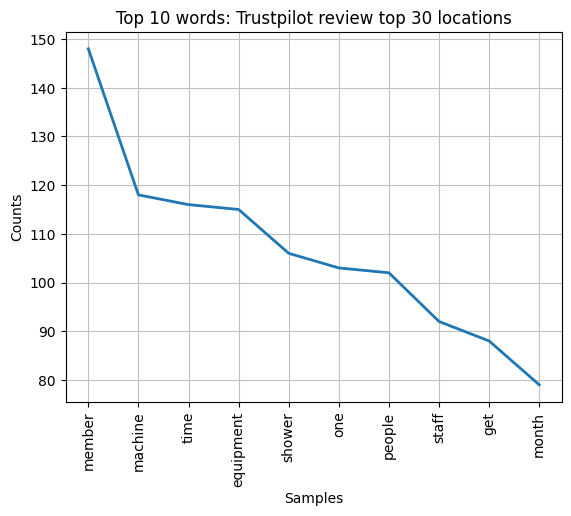

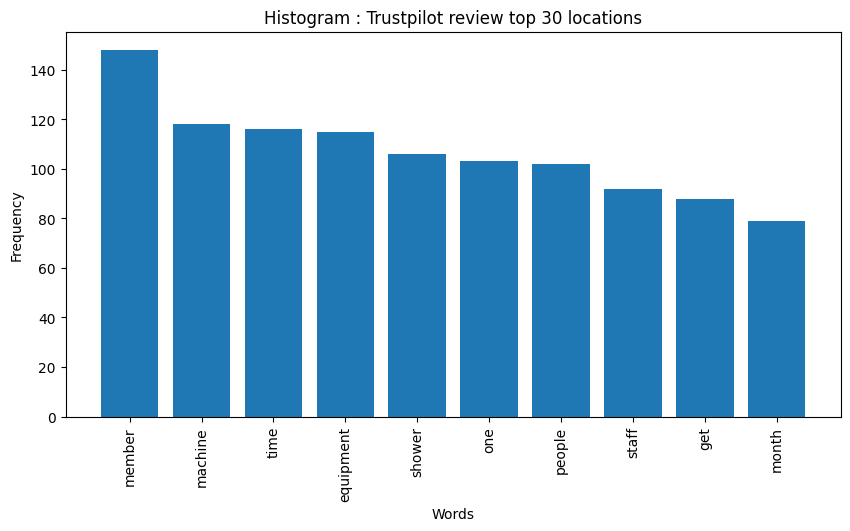

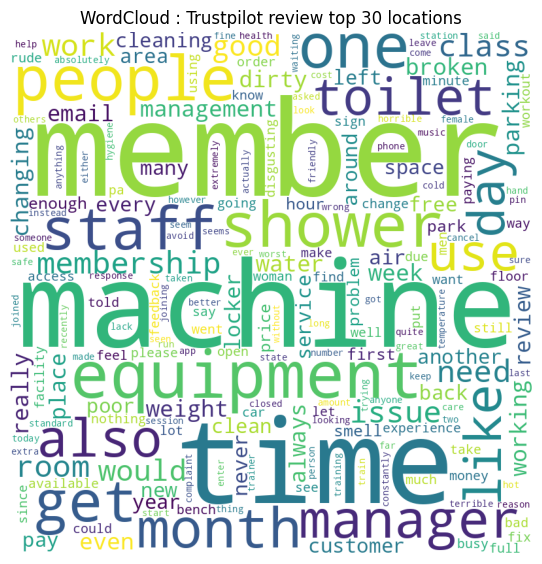

In [ ]:
# Plot Frequency distribution, Histogram and Word cloud
find_freq_dist(trustpilot_neg_top30_comments_list, 'Trustpilot review top 30 locations')

### Topic Modeling using BERT- top 30 locations (used T4)
Combine the reviews from Google and Trustpilot and run them through BERTopic.

Comment on the following:

• Are the results any different from the first run of BERTopic?
• If so, what has changed?
• Are there any additional insights compared to the first run?

In [ ]:
merged_reviews_df.head()

,Location,Review Comment,Emotion
0,Cambridge Leisure Park,many student two local college leave rubbish c...,1
1,Bristol Union Gate,current member quite dirty often soap bathroom...,1
2,New Barnet,way hot even workout window open barely work s...,2
3,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
4,Newcastle Eldon Garden,year finally leaving gutted staff lovely stand...,2


In [ ]:
merged_reviews_top30byLocation = merged_reviews_df[merged_reviews_df['Location'].isin(merged_neg_reviews_locations_sorted['Location'].head(30))]
merged_reviews_top30byLocation.head()

,Location,Review Comment,Emotion
2,New Barnet,way hot even workout window open barely work s...,2
6,New Barnet,airconditioning doesnt work,1
14,London Hoxton,staff allowed blame annoying people hoxton get...,1
15,Walsall Crown Wharf,absolute filthy toilet machine machine usually...,1
21,Burnham,overcrowded full teenager look plus would real...,1


In [ ]:
# Reset the index of merged_reviews_top30byLocation before fitting the model
merged_reviews_top30byLocation = merged_reviews_top30byLocation.reset_index(drop=True)

In [ ]:
model_top30 = BERTopic(verbose=True)
model_top30.fit(merged_reviews_top30byLocation['Review Comment'])
topic, probabilities = model_top30.transform(merged_reviews_top30byLocation['Review Comment'])

2025-03-29 15:43:50,673 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

2025-03-29 15:44:14,916 - BERTopic - Embedding - Completed ✓
2025-03-29 15:44:14,917 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-29 15:44:17,281 - BERTopic - Dimensionality - Completed ✓
2025-03-29 15:44:17,282 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-29 15:44:17,319 - BERTopic - Cluster - Completed ✓
2025-03-29 15:44:17,324 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-03-29 15:44:17,386 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

2025-03-29 15:44:40,878 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-03-29 15:44:40,883 - BERTopic - Dimensionality - Completed ✓
2025-03-29 15:44:40,884 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-03-29 15:44:40,915 - BERTopic - Cluster - Completed ✓


In [ ]:
model_top30.get_topic_freq().head(10)

,Topic,Count
3,-1,274
2,0,124
0,1,106
11,2,54
1,3,46
4,4,46
9,5,40
6,6,36
12,7,35
14,8,32


In [ ]:
model_top30.get_topic(0)

[('toilet', np.float64(0.05466099137374165)),
 ('cleaning', np.float64(0.041838761008656286)),
 ('smell', np.float64(0.04167491674273094)),
 ('dirty', np.float64(0.0405983429390236)),
 ('equipment', np.float64(0.028046119438415645)),
 ('hand', np.float64(0.026977372790206518)),
 ('disgusting', np.float64(0.026059397411485705)),
 ('smelly', np.float64(0.025886116147732615)),
 ('place', np.float64(0.02483597844077391)),
 ('room', np.float64(0.023581509738887344))]

In [ ]:
model_top30.get_topic(1)

[('manager', np.float64(0.03129172085304223)),
 ('member', np.float64(0.02967040187157158)),
 ('staff', np.float64(0.02787859336796737)),
 ('rude', np.float64(0.025771372061030147)),
 ('trainer', np.float64(0.022252366618696496)),
 ('review', np.float64(0.019189015568286037)),
 ('woman', np.float64(0.019100032680778804)),
 ('people', np.float64(0.016622414939693738)),
 ('would', np.float64(0.014694837682613928)),
 ('experience', np.float64(0.014589684517625755))]

In [ ]:
model_top30.visualize_topics()

In [ ]:
model_top30.visualize_barchart(top_n_topics=10)

In [ ]:
model_top30.visualize_heatmap()

# Conducting emotion analysis

In [ ]:
classifier = pipeline("text-classification", model='bhadresh-savani/bert-base-uncased-emotion', return_all_scores=True)

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
test_prompt_positive = "Great gym, always filled with a positive atmosphere from other people."

In [ ]:
test_prompt_negative = "The floor is extremely dirty to the point where you cant put a jumper on the floor."

In [ ]:
emotion_labels = classifier(test_prompt_positive, )

In [ ]:
emotion_labels_sorted = sorted(emotion_labels[0], key=lambda x: x["score"], reverse=True)

In [ ]:
print(emotion_labels_sorted)

[{'label': 'joy', 'score': 0.9987609386444092}, {'label': 'love', 'score': 0.0003318412636872381}, {'label': 'sadness', 'score': 0.0003264916012994945}, {'label': 'surprise', 'score': 0.00025158797507174313}, {'label': 'anger', 'score': 0.00019996589981019497}, {'label': 'fear', 'score': 0.00012915622210130095}]


In [ ]:
# Print the top emotion
print(emotion_labels_sorted[0]['label'])

joy


In [ ]:
emotion_labels_negative = classifier(test_prompt_negative)

In [ ]:
emotion_labels_negative_sorted = sorted(emotion_labels_negative[0], key=lambda x: x["score"], reverse=True)

In [ ]:
print(emotion_labels_negative_sorted)

[{'label': 'sadness', 'score': 0.9937703013420105}, {'label': 'anger', 'score': 0.0027617039158940315}, {'label': 'fear', 'score': 0.002497486537322402}, {'label': 'surprise', 'score': 0.00041771671385504305}, {'label': 'love', 'score': 0.00034089109976775944}, {'label': 'joy', 'score': 0.00021184726210776716}]


In [ ]:
from transformers import pipeline, AutoTokenizer

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained('bhadresh-savani/bert-base-uncased-emotion')

In [ ]:
# Function to perform emotion analysis using classifier on google_df_clean_negative and trustpilot_df_clean_negative on the review comments and add a column with the emotion labels and another column with top emotion

def emotion_analysis(df, column):
  # Function to truncate text to BERT's maximum input length
  def truncate_text(text):
    tokens = tokenizer.tokenize(text)
    if len(tokens) > tokenizer.model_max_length - 2:  # Account for [CLS] and [SEP] tokens
      tokens = tokens[:tokenizer.model_max_length - 2]
      text = tokenizer.convert_tokens_to_string(tokens)
    return text

  df[column] = df[column].apply(truncate_text)

  df['emotion_labels'] = df[column].apply(lambda x: classifier(x))
  df['top_emotion'] = df['emotion_labels'].apply(lambda x: sorted(x[0], key=lambda x: x["score"], reverse=True)[0]['label'])

  return df

## Emotion analysis on Google Review
Data set for entire list of Negative review: google_df_clean_negative

In [ ]:
# Perform emotion_analysis on google_df_clean_negative['Comment']
google_review_neg_emotion = emotion_analysis(google_df_clean_negative, 'Comment')
google_review_neg_emotion.head()

Token indices sequence length is longer than the specified maximum sequence length for this model (594 > 512). Running this sequence through the model will result in indexing errors


,Club's Name,Creation Date,Comment,Overall Score,emotion_labels,top_emotion
1,Cambridge Leisure Park,2024-05-09 22:48:39,many student two local college leave rubbish c...,1,"[[{'label': 'sadness', 'score': 0.001502163941...",anger
4,Bristol Union Gate,2024-05-09 21:48:00,current member quite dirty often soap bathroom...,1,"[[{'label': 'sadness', 'score': 0.862472832202...",sadness
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,kom betalte prøvetime centret fik blot rundvis...,1,"[[{'label': 'sadness', 'score': 0.166290253400...",joy
7,New Barnet,2024-05-09 20:16:04,way hot even workout window open barely work s...,2,"[[{'label': 'sadness', 'score': 0.001838678959...",anger
19,Manchester Cheetham Hill,2024-05-09 17:03:50,access empty assistance gain access fault forg...,2,"[[{'label': 'sadness', 'score': 0.990531682968...",sadness


<Axes: title={'center': 'Top emotion distribution: Google negative reviews'}, xlabel='top_emotion'>

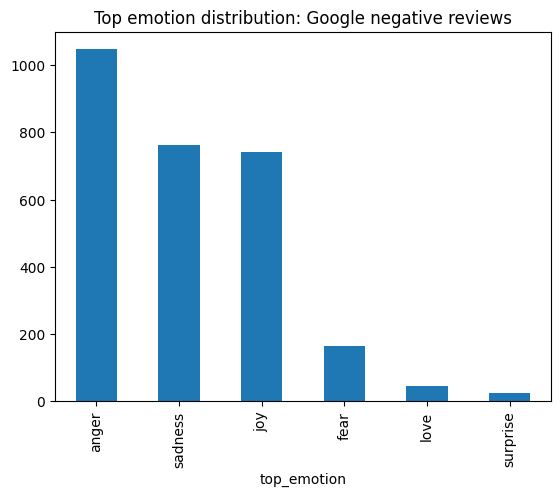

In [ ]:
# Plot a bar chart to show top_emotion distribution
google_review_neg_emotion['top_emotion'].value_counts().plot(kind='bar', title='Top emotion distribution: Google negative reviews')

## Addtional analysis-Not in Rubric
Joy as a top emotion looks out of place. Analysed further by reviews few random samples

In [ ]:
# Print the top 10 Comments where top_emotion is joy
google_review_neg_emotion[google_review_neg_emotion['top_emotion'] == 'joy'].head(10)

,Club's Name,Creation Date,Comment,Overall Score,emotion_labels,top_emotion
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,kom betalte prøvetime centret fik blot rundvis...,1,"[[{'label': 'sadness', 'score': 0.166290253400...",joy
95,Salford,2024-05-08 15:06:34,definitely spacious cancel membership full wor...,1,"[[{'label': 'sadness', 'score': 0.000542802328...",joy
121,London Holloway Road,2024-05-08 02:58:32,became super overcrowded impossible workout,1,"[[{'label': 'sadness', 'score': 0.000786119373...",joy
130,Byfleet,2024-05-08 00:47:07,compact need space equipment,2,"[[{'label': 'sadness', 'score': 0.002919257618...",joy
145,London Greenwich,2024-05-07 20:24:14,used good manager clearly decided lock window ...,2,"[[{'label': 'sadness', 'score': 0.001081053633...",joy
205,London Acton,2024-05-06 21:18:48,terrible experience enid ago made fun bad slow...,2,"[[{'label': 'sadness', 'score': 0.000778922345...",joy
230,Birmingham Snow Hill,2024-05-06 14:54:22,could please lower music volume everyone share...,1,"[[{'label': 'sadness', 'score': 0.000563474022...",joy
258,Leeds Thorpe Park,2024-05-06 01:55:49,going since moved thorpe park month ago facili...,2,"[[{'label': 'sadness', 'score': 0.000247956311...",joy
263,London Shoreditch High Street,2024-05-06 00:24:50,good,2,"[[{'label': 'sadness', 'score': 0.005436567123...",joy
336,London Wandsworth,2024-05-04 19:25:53,ultimately reason withdrew membership previous...,2,"[[{'label': 'sadness', 'score': 0.017067246139...",joy


In [ ]:
google_review_neg_emotion['Comment'][130]

'compact need space equipment'

In [ ]:
# Create a function to get top emotion when a test prompt is passed

def get_top_emotion(prompt):
  emotion_labels = classifier(prompt)
  emotion_labels_sorted = sorted(emotion_labels[0], key=lambda x: x["score"], reverse=True)

  return emotion_labels_sorted[0]['label']

There are considerably high numbers of negative comments which have Joy as top emotion. On further analysis of individual comments it feels like either the Overall Score have been incorrectly submitted or the comments have few words which have very positive emotion attached, which may have been scarcastic, or due to truncation/ stop words getting removed.
It may be better to run this on original dataset without cleaning comments.
There were few non-english comments, which too have been analysed. Not sure if how many languages does this model support. Worth investigating further.

kom betalte prøvetime centret fik blot rundvisning ingen instruktioner til trods jeg nævnte jeg ikke havde kendskab til maskinerne intet tidspunkt henvendte personalet sig til mig har jeg selv ret godt styr hvordan min krop virker tænker dem der som helt uvidende kommer ind hvilke skader kan påføre sig selv ved uhensigtsmæssige øvelser dybt uansvarligt:

Translation:
came paid for a trial lesson, the center was just given a tour, no instructions, despite me mentioning that I had no knowledge of the machines, at no time did the staff approach me, I have a pretty good handle on how my body works, think about those who come in completely unaware, what kind of damage they can cause themselves by inappropriate exercises, deeply irresponsible

In [ ]:
# Translation- Used google translator. Language detected-Danish

test_prompt_5 = 'came paid for a trial lesson, the center was just given a tour, no instructions, despite me mentioning that I had no knowledge of the machines, at no time did the staff approach me, I have a pretty good handle on how my body works, think about those who come in completely unaware, what kind of damage they can cause themselves by inappropriate exercises, deeply irresponsible'

In [ ]:
top_emotion = get_top_emotion(test_prompt_5)
print(top_emotion)

fear


Original top emotion: JOY.

emotion on english translation: FEAR.

It clearly shows that there are incorrect emotions when non-english text is passed. It would be better to drop these reviews if we could detect language and skip before passing to the classifier.


In [ ]:
# Original review: compactneed space equipment
# My interpretation: small but need more space and equipment
test_prompt_130 ='small but need more space and equipment'

In [ ]:
top_emotion = get_top_emotion(test_prompt_130)
print(top_emotion)

sadness


Original top emotion: JOY.

My interpretation after rephrasing: SADNESS.

So clearly there can be misrepresentation and it would be recommended to consider this analysis result as an overall sentiment, while detailed review of the comments need to be performed to actionize.

In [ ]:
# Print count of NaN or null values in top_emotion column
google_review_neg_emotion['top_emotion'].isnull().sum()

np.int64(0)

## Emotion analysis on Trustpilot Review
Data set for entire list of Negative review: trustpilot_df_clean_negative

In [ ]:
# Perform emotion_analysis on trustpilot_df_clean_negative['Review Content']
trustpilot_review_neg_emotion = emotion_analysis(trustpilot_df_clean_negative, 'Review Content')
trustpilot_review_neg_emotion.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name,emotion_labels,top_emotion
2,2024-05-09 22:51:00,Extremely busy,extremely busy fresh air,1,en,NaT,Sutton Times Square,"[[{'label': 'sadness', 'score': 0.054479438811...",joy
19,2024-05-09 18:09:00,The men’s changing rooms smell bad,men changing room smell bad need deep clean so...,2,en,NaT,Leeds City Centre South,"[[{'label': 'sadness', 'score': 0.020122816786...",joy
35,2024-05-09 13:25:00,All I wanted to do was set up another…,wanted set another debit card direct debit opt...,1,en,NaT,NaN,"[[{'label': 'sadness', 'score': 0.002285201102...",joy
36,2024-05-09 13:17:00,What ever you do don’t downgrade your…,ever downgrade membership core plus… cancel me...,1,en,NaT,NaN,"[[{'label': 'sadness', 'score': 0.189482674002...",anger
38,2024-05-09 12:35:00,Awful Gyms,poor parking enough kit unhelpful trainers sta...,2,en,NaT,NaN,"[[{'label': 'sadness', 'score': 0.529734551906...",sadness


<Axes: title={'center': 'Top emotion distribution: Trustpilot negative reviews'}, xlabel='top_emotion'>

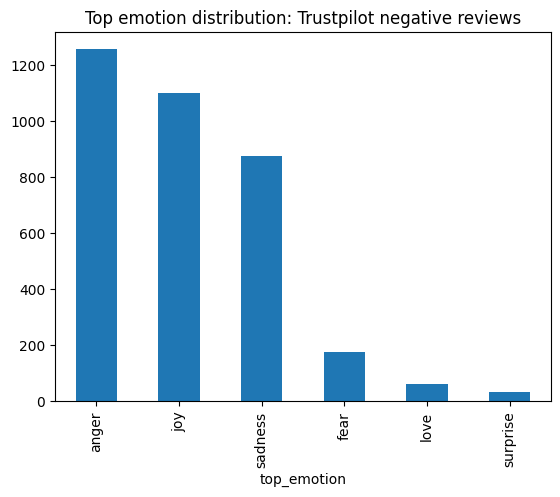

In [ ]:
# Plot a bar chart to show top_emotion distribution
trustpilot_review_neg_emotion['top_emotion'].value_counts().plot(kind='bar', title='Top emotion distribution: Trustpilot negative reviews')

This dataset also has high number of negative reviews which is classified as "Joy".

# Extract all negative reviews where anger is the top emotion

In [ ]:
google_review_neg_emotion.head()

,Club's Name,Creation Date,Comment,Overall Score,emotion_labels,top_emotion
1,Cambridge Leisure Park,2024-05-09 22:48:39,many student two local college leave rubbish c...,1,"[[{'label': 'sadness', 'score': 0.001502163941...",anger
4,Bristol Union Gate,2024-05-09 21:48:00,current member quite dirty often soap bathroom...,1,"[[{'label': 'sadness', 'score': 0.862472832202...",sadness
5,"209 - Slagelse, Jernbanegade",2024-05-09 21:36:17,kom betalte prøvetime centret fik blot rundvis...,1,"[[{'label': 'sadness', 'score': 0.166290253400...",joy
7,New Barnet,2024-05-09 20:16:04,way hot even workout window open barely work s...,2,"[[{'label': 'sadness', 'score': 0.001838678959...",anger
19,Manchester Cheetham Hill,2024-05-09 17:03:50,access empty assistance gain access fault forg...,2,"[[{'label': 'sadness', 'score': 0.990531682968...",sadness


In [ ]:
google_review_neg_emotion_anger = pd.DataFrame()

In [ ]:
# Create a new dataframe for all negative google reviews from google_review_neg_emotion where top emotion is anger

google_review_neg_emotion_anger = google_review_neg_emotion[google_review_neg_emotion['top_emotion'] == 'anger']

#Drop all columns except Club's Name, Comment and top_emotion
google_review_neg_emotion_anger = google_review_neg_emotion_anger.drop(columns=['Overall Score', 'Creation Date', 'emotion_labels'])

# rename columns as Location, Review Comment, Emotion
google_review_neg_emotion_anger.columns = ['Location', 'Review Comment', 'Emotion']

google_review_neg_emotion_anger.head()

,Location,Review Comment,Emotion
1,Cambridge Leisure Park,many student two local college leave rubbish c...,anger
7,New Barnet,way hot even workout window open barely work s...,anger
57,London Oval,huge equipment could easily fit double amount ...,anger
65,New Barnet,airconditioning doesnt work,anger
67,Rochdale,friend new joined struggling get scanner worki...,anger


In [ ]:
google_review_neg_emotion_anger.shape

(1046, 3)

In [ ]:
trustpilot_review_neg_emotion.head()

,Review Created (UTC),Review Title,Review Content,Review Stars,Review Language,Company Reply Date (UTC),Location Name,emotion_labels,top_emotion
2,2024-05-09 22:51:00,Extremely busy,extremely busy fresh air,1,en,NaT,Sutton Times Square,"[[{'label': 'sadness', 'score': 0.054479438811...",joy
19,2024-05-09 18:09:00,The men’s changing rooms smell bad,men changing room smell bad need deep clean so...,2,en,NaT,Leeds City Centre South,"[[{'label': 'sadness', 'score': 0.020122816786...",joy
35,2024-05-09 13:25:00,All I wanted to do was set up another…,wanted set another debit card direct debit opt...,1,en,NaT,NaN,"[[{'label': 'sadness', 'score': 0.002285201102...",joy
36,2024-05-09 13:17:00,What ever you do don’t downgrade your…,ever downgrade membership core plus… cancel me...,1,en,NaT,NaN,"[[{'label': 'sadness', 'score': 0.189482674002...",anger
38,2024-05-09 12:35:00,Awful Gyms,poor parking enough kit unhelpful trainers sta...,2,en,NaT,NaN,"[[{'label': 'sadness', 'score': 0.529734551906...",sadness


In [ ]:
# Create a new dataframe for all negative trust pilot reviews from trustpilot_review_neg_emotion where top emotion is anger

trustpilot_review_neg_emotion_anger = trustpilot_review_neg_emotion[trustpilot_review_neg_emotion['top_emotion'] == 'anger']

# Drop all columns except Review Content, Location Name	and top_emotion
trustpilot_review_neg_emotion_anger = trustpilot_review_neg_emotion_anger.drop(columns=['Review Created (UTC)','Review Title','Review Stars', 'Review Language','Company Reply Date (UTC)','emotion_labels','emotion_labels'])

# rename columns as Location, Review Comment, Emotion
trustpilot_review_neg_emotion_anger.columns = ['Review Comment', 'Location', 'Emotion']

trustpilot_review_neg_emotion_anger.head()

,Review Comment,Location,Emotion
36,ever downgrade membership core plus… cancel me...,NaN,anger
49,payed twice still didnt get day pas,NaN,anger
59,got raped location multiple time wait sorry me...,345,anger
105,blocked access take day work meet idiot manage...,Southampton Bitterne,anger
119,suspension notice staff time joining,NaN,anger


In [ ]:
trustpilot_review_neg_emotion_anger.shape

(1257, 3)

In [ ]:
# Merge google_review_neg_emotion_anger and trustpilot_review_neg_emotion_anger
merged_review_neg_emotion_anger = pd.concat([google_review_neg_emotion_anger, trustpilot_review_neg_emotion_anger])
merged_review_neg_emotion_anger.head()

,Location,Review Comment,Emotion
1,Cambridge Leisure Park,many student two local college leave rubbish c...,anger
7,New Barnet,way hot even workout window open barely work s...,anger
57,London Oval,huge equipment could easily fit double amount ...,anger
65,New Barnet,airconditioning doesnt work,anger
67,Rochdale,friend new joined struggling get scanner worki...,anger


In [ ]:
merged_review_neg_emotion_anger.shape

(2303, 3)

## Saved : merged_review_neg_emotion_anger.npy

In [ ]:
save_to_numpy(merged_review_neg_emotion_anger, 'merged_review_neg_emotion_anger.npy')

## Load dataset: merged_review_neg_emotion_anger.npy

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
print(np.__version__)

2.0.2


In [ ]:
loaded_merged_review_neg_emotion_anger = np.load('merged_review_neg_emotion_anger.npy', allow_pickle=True)

In [ ]:
# Convert loaded numpy dataset to pandas dataframe
merged_review_neg_emotion_anger = pd.DataFrame(loaded_merged_review_neg_emotion_anger)
merged_review_neg_emotion_anger.head()

,0,1,2
0,Cambridge Leisure Park,many students two local colleges leave rubbish...,anger
1,New Barnet,way hot even workout windows open barely works...,anger
2,London Oval,huge equipment could easily fit double amount ...,anger
3,New Barnet,airconditioning doesnt work,anger
4,Rochdale,friend new joined struggling get scanner worki...,anger


In [ ]:
# Rename column as Location, Review Comment, Emotion
merged_review_neg_emotion_anger.columns = ['Location', 'Review Comment', 'Emotion']
merged_review_neg_emotion_anger.head()

,Location,Review Comment,Emotion
0,Cambridge Leisure Park,many students two local colleges leave rubbish...,anger
1,New Barnet,way hot even workout windows open barely works...,anger
2,London Oval,huge equipment could easily fit double amount ...,anger
3,New Barnet,airconditioning doesnt work,anger
4,Rochdale,friend new joined struggling get scanner worki...,anger


In [ ]:
# Reset the index of merged_reviews_top30byLocation before fitting the model
merged_review_neg_emotion_anger = merged_review_neg_emotion_anger.reset_index(drop=True)

## Run BERTopic on merged review with anger as emotion

In [ ]:
model_anger = BERTopic(verbose=True)
model_anger.fit(merged_review_neg_emotion_anger['Review Comment'])
topic, probabilities = model_anger.transform(merged_review_neg_emotion_anger['Review Comment'])

2025-03-29 16:23:28,047 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

2025-03-29 16:24:29,719 - BERTopic - Embedding - Completed ✓
2025-03-29 16:24:29,720 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-29 16:24:38,878 - BERTopic - Dimensionality - Completed ✓
2025-03-29 16:24:38,880 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-29 16:24:39,039 - BERTopic - Cluster - Completed ✓
2025-03-29 16:24:39,045 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-03-29 16:24:39,224 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

2025-03-29 16:25:39,265 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-03-29 16:25:39,275 - BERTopic - Dimensionality - Completed ✓
2025-03-29 16:25:39,276 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-03-29 16:25:39,377 - BERTopic - Cluster - Completed ✓


In [ ]:
model_anger.get_topic_freq().head(10)

,Topic,Count
0,-1,887
6,0,207
5,1,132
24,2,70
17,3,58
9,4,52
10,5,48
13,6,48
14,7,48
12,8,48


In [ ]:
model_anger.get_topic(0)

[('der', np.float64(0.05256349897305739)),
 ('det', np.float64(0.04224361710109168)),
 ('ikke', np.float64(0.04143815396243134)),
 ('und', np.float64(0.03837450964197508)),
 ('die', np.float64(0.03691860435994146)),
 ('nicht', np.float64(0.0345034744471851)),
 ('man', np.float64(0.03413683615649054)),
 ('ich', np.float64(0.030978924148014248)),
 ('til', np.float64(0.03049487845820153)),
 ('jeg', np.float64(0.0285963771893381))]

In [ ]:
model_anger.get_topic(1)

[('toilet', np.float64(0.08219080616996047)),
 ('cleaning', np.float64(0.052085627485060786)),
 ('changing', np.float64(0.032688666834655565)),
 ('station', np.float64(0.031106522262183564)),
 ('room', np.float64(0.029900890873317463)),
 ('disgusting', np.float64(0.02853971561216962)),
 ('hand', np.float64(0.027089961677736193)),
 ('dirty', np.float64(0.026929010435415086)),
 ('filthy', np.float64(0.024651122702361822)),
 ('paper', np.float64(0.024031366384016577))]

In [ ]:
model_anger.visualize_topics()

In [ ]:
model_anger.visualize_barchart(top_n_topics=10)

In [ ]:
model_anger.visualize_heatmap()

# Using a LLM Phi 3.5 from Hugging Face

## Install transformers 4.48 for Phi 3.5

In [ ]:
!pip install transformers==4.48

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 57.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.50.0
    Uninstalling transformers-4.50.0:
      Successfully uninstalled transformers-4.50.0


## Import Libraries

In [ ]:
import json

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

In [ ]:
torch.random.manual_seed(0)

In [ ]:
import re
from more_itertools import chunked  # For splitting the list into batches

## Phi 3.5 model

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3.5-mini-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3.5-mini-instruct")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/3.45k [00:00<?, ?B/s]

configuration_phi3.py:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py:   0%|          | 0.00/73.8k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/3.98k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [ ]:
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

Device set to use cuda


In [ ]:
generation_args = {
    "max_new_tokens": 1000,
    "return_full_text": False,
    "temperature": 0.0,
    "do_sample": False,
}

In [ ]:
# Convert merged_review_neg_emotion_anger['Review Comment'] to a list
merged_review_neg_emotion_anger_list = merged_review_neg_emotion_anger['Review Comment'].tolist()

In [ ]:
# Check if the list has any NaN or null data
sum(pd.isnull(x) for x in merged_review_neg_emotion_anger_list)

0

In [ ]:
len(merged_review_neg_emotion_anger_list)

2346

In [ ]:
merged_review_neg_emotion_anger_list[0]

'many students two local colleges leave rubbish changing rooms sit like canteen going years cancel membership group disgusting students hanging around machines messing around like school crowded ceo supports genocide civilians israel disgusting people'

## Text generation-Topics

In [ ]:
from more_itertools import chunked

In [ ]:
# Initialize an empty list to store raw outputs
topics_llm_raw = []

# Define the chunk size
chunk_size = 50  # Adjust this based on available resources

# Process reviews in chunks
for review_chunk in chunked(merged_review_neg_emotion_anger_list[0:100], chunk_size):
    # Filter reviews with length less than 1000
    filtered_reviews = [review for review in review_chunk if len(str(review)) < 1000]

    if filtered_reviews:  # Skip empty chunks
        # Batch create messages for each review in the chunk
        messages_list = [
            [
                {"role": "system", "content": "You work as a data scientist for a large gym company and you want to find topics from negative customer reviews to recommend improvements. You should return these in an array of strings only ['topic 1', 'topic 2', 'topic 3', ...]"},
                {"role": "user", "content": "In the following customer review interaction pick out a maximum of 3 main topics and return them as an array of topics: The showers are disgusting"},
                {"role": "assistant", "content": "['Shower cleanliness', 'odour', 'customer discomfort']"},
                {"role": "user", "content": f"In the following customer review interaction pick out the main 3 topics and return them as an array of topics: {review}"}
            ]
            for review in filtered_reviews
        ]

        # Process all messages in the current batch
        outputs = pipe(messages_list, **generation_args)  # Pass the batch to the pipeline

        # Append all outputs to the raw output list
        topics_llm_raw.extend(outputs)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
`get_max_cache()` is deprecated for all Cache classes. Use `get_max_cache_shape()` instead. Calling `get_max_cache()` will raise error from v4.48


In [ ]:
outputs

[[{'generated_text': ' [\'Studio maintenance and renovation\', \'Sanitation and cleanliness\', \'Security and personal belongings\']\n\nExplanation:\n\n1. \'Studio maintenance and renovation\': The review mentions that the studio is in a "heruntergekommen" (run-down) state, suggesting that it requires maintenance or renovation.\n\n2. \'Sanitation and cleanliness\': The review describes the equipment as "dreckig" (dirty) and "verstaubt" (dusty), indicating a lack of cleanliness.\n\n3. \'Security and personal belongings\': The mention of needing to "bringen eigene schlösser" (bring your own locks) implies concerns about security and the protection of personal belongings within the studio.\n\nThese topics are derived from the key issues raised in the review and are relevant for the gym company to address in order to improve customer satisfaction.'}],
 [{'generated_text': ' [\'Payment issues\', \'Lack of service\', \'Overpricing\']\n\nHere\'s a breakdown of the topics identified from the c

In [ ]:
topics_llm_raw[98]

[{'generated_text': ' [\'Day pass duration\', \'booking process\', \'equipment quality and customer service\']\n\nHere\'s the breakdown of the topics extracted from the customer review:\n\n1. **Day pass duration**: The customer is concerned about the length of time the day pass is supposed to last, as they mention it "assumed lasted hours" but it "didn\'t arrive" and "expires midnight."\n\n2. **Booking process**: The review includes complaints about the booking process being an "absolute shambles" and a "scam," with the customer stating they "reject door within hours" of booking.\n\n3. **Equipment quality and customer service**: The customer mentions "better equipment" and "somebody speak," indicating dissatisfaction with the gym\'s equipment and the quality of customer service they received.\n\nThese topics are critical areas that the gym company should address to improve customer satisfaction and prevent negative reviews.'}]

In [ ]:
# Extract topics for each review in the batch
topics_llm_cleaned = []
for output in topics_llm_raw:
    topic_list_string = output[0]['generated_text']
    # Get the first line from topic_list_string
    first_line = topic_list_string.split('\n')[0].replace("'", '"')
    # print(first_line)

    # If first_line is not compatable with json.loads, skip
    try:
        topic_list = json.loads(first_line)
    except json.JSONDecodeError:
        continue

    topics_llm_cleaned.append(topic_list)

In [ ]:
print(topics_llm_cleaned)

[['Littering and cleanliness', 'Overcrowding and management', 'Inappropriate behavior and safety concerns'], ['Workout equipment functionality', 'Staff behavior and customer service', 'Client satisfaction and safety concerns'], ['Equipment capacity', 'underutilization', 'facility potential'], ['Air conditioning functionality', 'climate control', 'customer discomfort'], ['Scanner malfunction', 'Member support issues', 'Poor member etiquette and hygiene'], ['Hygiene standards', 'Staff behavior', 'Customer service experience'], ['Maintenance issues', 'Poor management', 'Staff behavior and customer service'], ['Toilet cleanliness and maintenance', 'Sanitization and hygiene practices', 'Staff knowledge and customer service'], ['Monthly charges reduction', 'Lack of promotions', 'Service quality at Base Fit'], ['Poor climate control', 'Outdated equipment', 'Overpriced service'], ['Store layout', 'Insufficient equipment', 'Overcrowding and noise'], ['Air conditioning effectiveness', 'sweatines

In [ ]:
# Flatten topics_llm and remove duplicates
flattened_topics = [topic for sublist in topics_llm_cleaned for topic in sublist]
unique_topics = list(set(flattened_topics))

print(unique_topics)

['Hygiene and sanitation', 'Store layout', 'Theft incidents', 'Insufficient parking spaces', 'equipment quality and customer service', 'Service quality and pricing concerns', 'Broken equipment', 'Air conditioning effectiveness', 'Customer dissatisfaction and potential membership cancellation', 'cleanliness', 'Issues with direct debit setup and communication', 'Toilet cleanliness and maintenance', 'Poor communication and organization', 'Cost-cutting measures and customer service', 'public health risk', 'Membership cancellation process', 'Noise and disturbances', 'Customer experience', 'Air conditioning odor', 'Long wait times', 'Client dissatisfaction with trainers', 'Cleanliness of machines', 'Gym rules and regulations', 'Personal safety threat', 'People traffic', 'Service quality at Base Fit', 'Poor professional conduct', 'Gender-based discrimination', 'Overcrowding and noise', 'Lack of communication', 'Cleaning paper quality', 'Unpleasant odor', 'Customer service expectations', 'seas

In [ ]:
np.save('np_topics_phi.npy', unique_topics)

## Text generation-Actions

In [ ]:
loaded_arr = np.load('np_topics_phi.npy', allow_pickle=True)
topics_llm = loaded_arr.tolist()

In [ ]:
print(topics_llm)

['Hygiene and sanitation', 'Store layout', 'Theft incidents', 'Insufficient parking spaces', 'equipment quality and customer service', 'Service quality and pricing concerns', 'Broken equipment', 'Air conditioning effectiveness', 'Customer dissatisfaction and potential membership cancellation', 'cleanliness', 'Issues with direct debit setup and communication', 'Toilet cleanliness and maintenance', 'Poor communication and organization', 'Cost-cutting measures and customer service', 'public health risk', 'Membership cancellation process', 'Noise and disturbances', 'Customer experience', 'Air conditioning odor', 'Long wait times', 'Client dissatisfaction with trainers', 'Cleanliness of machines', 'Gym rules and regulations', 'Personal safety threat', 'People traffic', 'Service quality at Base Fit', 'Poor professional conduct', 'Gender-based discrimination', 'Overcrowding and noise', 'Lack of communication', 'Cleaning paper quality', 'Unpleasant odor', 'Customer service expectations', 'seas

In [ ]:
messages_2 = [
        {"role": "system", "content": "You work as a data analyst for a large gym company."},
        {"role": "user", "content": """In the following list containing the main extracted topics from customer reviews, group or compress the topics into a maximum of ten actionable insights in a numbered list format:
        Topics: locker room cleanliness, overcrowding, sanitation and cleanliness"""},
        {"role": "assistant", "content": """1. Cleanliness
          - Actionable insight: Increase regular cleaning schedules and conduct surprise inspections.
          - Frequency: 2 mentions
        2. Equipment Maintenance:
          - Actionable insight: Review the status of gym equipment at all mentioned gyms and ensure a rigorous maintenance schedule is adhered to.
          - Frequency: 1 mention
        3. Staff Proffesionalism:
          - Actionable insight: Implement a comprehensive staff training program focused on customer service excellence.
          - Frequency: 1 mention"""},
        {"role": "user", "content": f"""In the following list containing the main extracted topics from customer reviews, group or compress the topics into a maximum of ten actionable insights in a numbered list format:
        Topics: {topics_llm} """}
    ]

In [ ]:
output = pipe(messages_2, **generation_args)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


In [ ]:
topic_list_string = output[0]['generated_text'].replace("'", '"')
print(topic_list_string)

 1. **Cleanliness and Sanitation**
   - Actionable insight: Implement a strict cleaning protocol and conduct regular audits to ensure high standards of hygiene and sanitation are maintained.
   - Frequency: 10 mentions

2. **Staff Professionalism and Behavior**
   - Actionable insight: Develop a comprehensive training program to improve staff professionalism, communication, and customer service skills.
   - Frequency: 5 mentions

3. **Equipment Maintenance and Quality**
   - Actionable insight: Establish a regular maintenance schedule for all equipment and invest in high-quality machines to reduce malfunctions and improve customer satisfaction.
   - Frequency: 5 mentions

4. **Customer Service Efficiency**
   - Actionable insight: Streamline customer service processes and provide additional training to staff to handle inquiries and complaints more effectively.
   - Frequency: 4 mentions

5. **Overcrowding and Noise Management**
   - Actionable insight: Implement a reservation system to

# Using Gensim on all negative reviews

## Gensim library and dependency installation

In [ ]:
!pip install gensim nltk datasets pyLDAvis ipykernel

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [ ]:
!pip install --upgrade --force-reinstall numpy scipy gensim

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64

In [ ]:
!pip install --upgrade --force-reinstall pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.7 MB/s eta 0:00:00
  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 28.5 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.1
    Uninstalling pytz-2025.1:
      Successfully uninstalled pytz-2025.1
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.1
    Uninstalling tzdata-2025.1:
      Successfully uninstalled tzdata-2025.1
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Success

## Load merged_review_neg_all numpy file

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
loaded_merged_review_neg_all = np.load('merged_negative_reviews_df.npy', allow_pickle=True)

In [ ]:
# Convert loaded numpy dataset to pandas dataframe
merged_review_neg_all = pd.DataFrame(loaded_merged_review_neg_all)
merged_review_neg_all.head()

,0,1,2
0,Cambridge Leisure Park,many students two local colleges leave rubbish...,1
1,Bristol Union Gate,current member quite dirty often theres soap b...,1
2,New Barnet,way hot even workout windows open barely works...,2
3,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
4,Newcastle Eldon Garden,year finally leaving gutted staff pts lovely c...,2


In [ ]:
# Rename column as Location, Review Comment, Emotion
merged_review_neg_all.columns = ['Location', 'Review Comment', 'Rating']
merged_review_neg_all.head()

,Location,Review Comment,Rating
0,Cambridge Leisure Park,many students two local colleges leave rubbish...,1
1,Bristol Union Gate,current member quite dirty often theres soap b...,1
2,New Barnet,way hot even workout windows open barely works...,2
3,Manchester Cheetham Hill,access empty assistance gain access fault forg...,2
4,Newcastle Eldon Garden,year finally leaving gutted staff pts lovely c...,2


## Import NLTK and string for preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
import string

In [ ]:
# Download necessary NLTK data.
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Define stop words and punctuation.
stop = set(stopwords.words('english'))
exclude = set(string.punctuation)
lemma = WordNetLemmatizer()

In [ ]:
# Function to clean the document.
def clean(doc):
    # Remove stop words and convert to lowercase.
    stop_free = " ".join([word for word in doc.lower().split() if word not in stop])
    # Remove punctuation.
    punc_free = ''.join(ch for ch in stop_free if ch not in exclude)
    # Lemmatise the text.
    normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
    return normalized

## Tokenize Reviews

In [ ]:
# clean merged_review_neg_emotion_anger['Review Comment']
merged_review_neg_all['Tokenized Comment'] = merged_review_neg_all['Review Comment'].apply(clean)

In [ ]:
#Tokenize the documents in Tokenized Comment
merged_review_neg_all['Tokenized Comment'] = merged_review_neg_all['Tokenized Comment'].apply(lambda x: x.split())

## Create dictionary and corpus

In [ ]:
# Create a dictionary representation of the documents.
from gensim import corpora

In [ ]:
dictionary = corpora.Dictionary(merged_review_neg_all['Tokenized Comment'])

In [ ]:
# Filter out words that occur fewer than 2 documents or more than 50% of the documents.
dictionary.filter_extremes(no_below=2, no_above=0.5)

In [ ]:
dictionary

## Build the LDA model using the dictionary and corpus

In [ ]:
# Create a BOW representation of the documents.
corpus = [dictionary.doc2bow(doc) for doc in merged_review_neg_all['Tokenized Comment']]

# Set parameters.
num_topics = 10
passes = 20

In [ ]:
# Create the LDA model.
from gensim.models.ldamodel import LdaModel
lda_model = LdaModel(
    corpus=corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=passes
    random_state=42
    )

## View topics

In [ ]:
# Print the topics.
for idx, topic in lda_model.print_topics(-1):
    print("Topic: {} \nWords: {}".format(idx, topic))

Topic: 0 
Words: 0.032*"machine" + 0.030*"air" + 0.029*"equipment" + 0.021*"broken" + 0.014*"working" + 0.013*"always" + 0.012*"time" + 0.010*"con" + 0.010*"conditioning" + 0.010*"water"
Topic: 1 
Words: 0.014*"issue" + 0.013*"customer" + 0.012*"experience" + 0.011*"member" + 0.011*"time" + 0.009*"would" + 0.009*"manager" + 0.009*"review" + 0.008*"closed" + 0.008*"staff"
Topic: 2 
Words: 0.070*"shower" + 0.039*"cold" + 0.037*"water" + 0.028*"hot" + 0.019*"temperature" + 0.015*"please" + 0.011*"warm" + 0.010*"month" + 0.009*"freezing" + 0.009*"issue"
Topic: 3 
Words: 0.026*"room" + 0.023*"toilet" + 0.023*"changing" + 0.016*"shower" + 0.016*"cleaning" + 0.014*"dirty" + 0.013*"locker" + 0.013*"equipment" + 0.010*"clean" + 0.009*"smell"
Topic: 4 
Words: 0.020*"membership" + 0.017*"get" + 0.015*"day" + 0.013*"email" + 0.012*"month" + 0.011*"service" + 0.011*"member" + 0.011*"staff" + 0.010*"access" + 0.009*"customer"
Topic: 5 
Words: 0.018*"staff" + 0.017*"member" + 0.014*"equipment" + 0.01

In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Prepare the visualisation.
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

# Using Gensim on negative reviews with Anger emotion

## Load dataset: merged_review_neg_emotion_anger.npy

In [ ]:
loaded_merged_review_neg_emotion_anger = np.load('merged_review_neg_emotion_anger.npy', allow_pickle=True)

In [ ]:
# Convert loaded numpy dataset to pandas dataframe
merged_review_neg_emotion_anger = pd.DataFrame(loaded_merged_review_neg_emotion_anger)
merged_review_neg_emotion_anger.head()

,0,1,2
0,Cambridge Leisure Park,many students two local colleges leave rubbish...,anger
1,New Barnet,way hot even workout windows open barely works...,anger
2,London Oval,huge equipment could easily fit double amount ...,anger
3,New Barnet,airconditioning doesnt work,anger
4,Rochdale,friend new joined struggling get scanner worki...,anger


In [ ]:
# Rename column as Location, Review Comment, Emotion
merged_review_neg_emotion_anger.columns = ['Location', 'Review Comment', 'Emotion']
merged_review_neg_emotion_anger.head()

,Location,Review Comment,Emotion
0,Cambridge Leisure Park,many students two local colleges leave rubbish...,anger
1,New Barnet,way hot even workout windows open barely works...,anger
2,London Oval,huge equipment could easily fit double amount ...,anger
3,New Barnet,airconditioning doesnt work,anger
4,Rochdale,friend new joined struggling get scanner worki...,anger


In [ ]:
# Reset the index of merged_reviews_top30byLocation before fitting the model
merged_review_neg_emotion_anger = merged_review_neg_emotion_anger.reset_index(drop=True)

In [ ]:
merged_review_neg_emotion_anger['Review Comment']

,Review Comment
0,many students two local colleges leave rubbish...
1,way hot even workout windows open barely works...
2,huge equipment could easily fit double amount ...
3,airconditioning doesnt work
4,friend new joined struggling get scanner worki...
...,...
2341,filthy wonder one antibac spray throughout ent...
2342,dont recommend jelena rude members overheard t...
2343,cancellation page work
2344,ive gone since restarted membership give secon...


In [ ]:
# clean merged_review_neg_emotion_anger['Review Comment']
merged_review_neg_emotion_anger['Tokenized Comment'] = merged_review_neg_emotion_anger['Review Comment'].apply(clean)

In [ ]:
#Tokenize the documents in Tokenized Comment
merged_review_neg_emotion_anger['Tokenized Comment'] = merged_review_neg_emotion_anger['Tokenized Comment'].apply(lambda x: x.split())

In [ ]:
merged_review_neg_emotion_anger.head()

,Location,Review Comment,Emotion,Tokenized Comment
0,Cambridge Leisure Park,many students two local colleges leave rubbish...,anger,"[many, student, two, local, college, leave, ru..."
1,New Barnet,way hot even workout windows open barely works...,anger,"[way, hot, even, workout, window, open, barely..."
2,London Oval,huge equipment could easily fit double amount ...,anger,"[huge, equipment, could, easily, fit, double, ..."
3,New Barnet,airconditioning doesnt work,anger,"[airconditioning, doesnt, work]"
4,Rochdale,friend new joined struggling get scanner worki...,anger,"[friend, new, joined, struggling, get, scanner..."


## Create dictionary and corpus

In [ ]:
# Create a dictionary representation of the documents.
from gensim import corpora

In [ ]:
dictionary = corpora.Dictionary(merged_review_neg_emotion_anger['Tokenized Comment'])

In [ ]:
# Filter out words that occur fewer than 2 documents or more than 50% of the documents.
dictionary.filter_extremes(no_below=2, no_above=0.5)

In [ ]:
dictionary

## Build the LDA model using the dictionary and corpus

In [ ]:
# Create a BOW representation of the documents.
corpus = [dictionary.doc2bow(doc) for doc in merged_review_neg_emotion_anger['Tokenized Comment']]

# Set parameters.
num_topics = 10
passes = 20

In [ ]:
# Create the LDA model.
from gensim.models.ldamodel import LdaModel
lda_model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary, passes=passes)

## View topics

In [ ]:
# Print the topics.
for idx, topic in lda_model.print_topics(-1):
    print("Topic: {} \nWords: {}".format(idx, topic))

Topic: 0 
Words: 0.032*"machine" + 0.030*"air" + 0.029*"equipment" + 0.021*"broken" + 0.014*"working" + 0.013*"always" + 0.012*"time" + 0.010*"con" + 0.010*"conditioning" + 0.010*"water"
Topic: 1 
Words: 0.014*"issue" + 0.013*"customer" + 0.012*"experience" + 0.011*"member" + 0.011*"time" + 0.009*"would" + 0.009*"manager" + 0.009*"review" + 0.008*"closed" + 0.008*"staff"
Topic: 2 
Words: 0.070*"shower" + 0.039*"cold" + 0.037*"water" + 0.028*"hot" + 0.019*"temperature" + 0.015*"please" + 0.011*"warm" + 0.010*"month" + 0.009*"freezing" + 0.009*"issue"
Topic: 3 
Words: 0.026*"room" + 0.023*"toilet" + 0.023*"changing" + 0.016*"shower" + 0.016*"cleaning" + 0.014*"dirty" + 0.013*"locker" + 0.013*"equipment" + 0.010*"clean" + 0.009*"smell"
Topic: 4 
Words: 0.020*"membership" + 0.017*"get" + 0.015*"day" + 0.013*"email" + 0.012*"month" + 0.011*"service" + 0.011*"member" + 0.011*"staff" + 0.010*"access" + 0.009*"customer"
Topic: 5 
Words: 0.018*"staff" + 0.017*"member" + 0.014*"equipment" + 0.01

In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Prepare the visualisation.
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)